# 02 Prophet Modeling

## Step 1: Aggregate and Split Without Leakage
Uses processed Yellow Taxi monthly files, aggregates to hourly demand, then applies strict time splits.


In [29]:
# Step 0: Pre-aggregation data inspection (run before Step 1)
from pathlib import Path
import re
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents, Path.home() / 'Documents/GitHub/nyc-mobility-analysis', Path.home() / 'Downloads/GitHub/nyc-mobility-analysis']
repo_root_probe = next((p for p in candidates if (p / 'data' / 'processed').exists()), None)
if repo_root_probe is None:
    raise FileNotFoundError('Cannot find repo root with data/processed')

processed_dir_probe = repo_root_probe / 'data' / 'processed'
pattern = re.compile(r'^yellow_tripdata_(\d{4}-\d{2})\.parquet$')
files_probe = []
for f in sorted(processed_dir_probe.glob('yellow_tripdata_*.parquet')):
    m = pattern.match(f.name)
    if m and '2024-01' <= m.group(1) <= '2025-12':
        files_probe.append(f)

assert all(f.name.startswith('yellow_tripdata_') for f in files_probe), 'Non-yellow file detected'

if not files_probe:
    raise FileNotFoundError(f'No monthly files found in {processed_dir_probe}')

file_summary = []
sample_frames = []
for fp in files_probe:
    tmp = pd.read_parquet(fp, columns=['pickup_datetime', 'dropoff_datetime', 'pickup_location_id'])
    tmp['pickup_datetime'] = pd.to_datetime(tmp['pickup_datetime'], errors='coerce')
    tmp['dropoff_datetime'] = pd.to_datetime(tmp['dropoff_datetime'], errors='coerce')
    row = {
        'file': fp.name,
        'rows': len(tmp),
        'pickup_min': tmp['pickup_datetime'].min(),
        'pickup_max': tmp['pickup_datetime'].max(),
        'null_pickup_pct': float(tmp['pickup_datetime'].isna().mean() * 100),
        'null_zone_pct': float(tmp['pickup_location_id'].isna().mean() * 100),
    }
    file_summary.append(row)
    sample_frames.append(tmp[['pickup_datetime', 'dropoff_datetime', 'pickup_location_id']].sample(min(5000, len(tmp)), random_state=42))

file_summary_df = pd.DataFrame(file_summary)
sample_df = pd.concat(sample_frames, ignore_index=True)
sample_df['trip_duration_hours'] = (sample_df['dropoff_datetime'] - sample_df['pickup_datetime']).dt.total_seconds() / 3600
global_checks = pd.DataFrame([
    {'check': 'sample_rows', 'value': int(len(sample_df))},
    {'check': 'sample_pickup_min', 'value': sample_df['pickup_datetime'].min()},
    {'check': 'sample_pickup_max', 'value': sample_df['pickup_datetime'].max()},
    {'check': 'sample_years', 'value': sorted(sample_df['pickup_datetime'].dropna().dt.year.unique().tolist())},
    {'check': 'negative_duration_pct', 'value': float((sample_df['trip_duration_hours'] < 0).mean() * 100)},
    {'check': 'gt_24h_duration_pct', 'value': float((sample_df['trip_duration_hours'] > 24).mean() * 100)},
])

print('Repo root:', repo_root_probe)
print('Files found:', len(files_probe))
print('First file:', files_probe[0].name)
print('Last file :', files_probe[-1].name)
print()
display(file_summary_df.head(10))
display(global_checks)


Repo root: /Users/racheldong/Documents/GitHub/nyc-mobility-analysis
Files found: 23
First file: yellow_tripdata_2024-01.parquet
Last file : yellow_tripdata_2025-11.parquet



,file,rows,pickup_min,pickup_max,null_pickup_pct,null_zone_pct
0,yellow_tripdata_2024-01.parquet,2788274,2002-12-31 22:59:39,2024-02-01 00:01:15,0.0,0.0
1,yellow_tripdata_2024-02.parquet,2785121,2008-12-31 22:52:49,2024-03-01 00:01:37,0.0,0.0
2,yellow_tripdata_2024-03.parquet,3111350,2002-12-31 22:17:10,2024-04-01 00:34:55,0.0,0.0
3,yellow_tripdata_2024-04.parquet,3061165,2002-12-31 22:10:04,2024-05-01 00:02:36,0.0,0.0
4,yellow_tripdata_2024-05.parquet,3269301,2002-12-31 16:46:07,2024-06-01 23:54:14,0.0,0.0
5,yellow_tripdata_2024-06.parquet,3078950,2008-12-31 00:00:00,2026-06-26 23:53:12,0.0,0.0
6,yellow_tripdata_2024-07.parquet,2746806,2009-01-01 00:02:24,2024-08-01 23:51:57,0.0,0.0
7,yellow_tripdata_2024-08.parquet,2666846,2009-01-01 00:02:52,2024-09-10 12:27:29,0.0,0.0
8,yellow_tripdata_2024-09.parquet,3092759,2008-12-31 23:03:46,2024-10-01 21:24:53,0.0,0.0
9,yellow_tripdata_2024-10.parquet,3378038,2009-01-01 00:35:59,2024-11-14 18:30:00,0.0,0.0


,check,value
0,sample_rows,115000
1,sample_pickup_min,2024-01-01 00:04:40
2,sample_pickup_max,2025-11-30 23:56:30
3,sample_years,"[2024, 2025]"
4,negative_duration_pct,0.0
5,gt_24h_duration_pct,0.0


In [30]:
from pathlib import Path
import re
import pandas as pd

# Robust project-root detection (works even if notebook launches from another cwd)
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
candidates += [
    Path.home() / "Documents/GitHub/nyc-mobility-analysis",
    Path.home() / "Downloads/GitHub/nyc-mobility-analysis",
]
repo_root = next((p for p in candidates if (p / "data" / "processed").exists()), None)

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate project root with data/processed. "
        "Set repo_root manually."
    )

processed_dir = repo_root / "data" / "processed"
output_dir = repo_root / "data" / "interim" / "prophet"
output_dir.mkdir(parents=True, exist_ok=True)

# Only monthly files in requested window
start_month = "2024-01"
end_month = "2025-12"  # safe upper bound; your current data ends at 2025-11
pattern = re.compile(r"^yellow_tripdata_(\d{4}-\d{2})\.parquet$")

files = []
for f in sorted(processed_dir.glob("yellow_tripdata_*.parquet")):
    m = pattern.match(f.name)
    if not m:
        continue
    month_key = m.group(1)
    if start_month <= month_key <= end_month:
        files.append(f)

if not files:
    raise FileNotFoundError(
        f"No monthly files found in {processed_dir} for [{start_month}, {end_month}]"
    )

print("cwd:", cwd)
print("repo_root:", repo_root)
print("processed_dir exists:", processed_dir.exists())
print(f"Using {len(files)} files")
print("first:", files[0].name)
print("last :", files[-1].name)


cwd: /Users/racheldong/Documents/GitHub/nyc-mobility-analysis/notebooks/exploratory/modeling
repo_root: /Users/racheldong/Documents/GitHub/nyc-mobility-analysis
processed_dir exists: True
Using 23 files
first: yellow_tripdata_2024-01.parquet
last : yellow_tripdata_2025-11.parquet


In [31]:
# Aggregate trip-level rows to hourly demand (city + zone)
city_chunks = []
zone_chunks = []

for fp in files:
    df = pd.read_parquet(fp, columns=['pickup_datetime', 'pickup_location_id'])
    df = df.dropna(subset=['pickup_datetime'])
    df['ds'] = pd.to_datetime(df['pickup_datetime']).dt.floor('h')

    # Keep only the intended modeling window to avoid bad historical timestamps
    lower = pd.Timestamp("2024-01-01 00:00:00")
    upper = pd.Timestamp("2025-12-31 23:59:59")
    df = df[(df["ds"] >= lower) & (df["ds"] <= upper)]

    city_part = df.groupby('ds', as_index=False).size().rename(columns={'size': 'y'})
    city_chunks.append(city_part)

    zone_part = (
        df.dropna(subset=['pickup_location_id'])
        .assign(zone_id=lambda x: x['pickup_location_id'].astype('int64'))
        .groupby(['zone_id', 'ds'], as_index=False)
        .size()
        .rename(columns={'size': 'y'})
    )
    zone_chunks.append(zone_part)

city_hourly = (
    pd.concat(city_chunks, ignore_index=True)
    .groupby('ds', as_index=False)['y']
    .sum()
    .sort_values('ds')
    .reset_index(drop=True)
)

zone_hourly = (
    pd.concat(zone_chunks, ignore_index=True)
    .groupby(['zone_id', 'ds'], as_index=False)['y']
    .sum()
    .sort_values(['zone_id', 'ds'])
    .reset_index(drop=True)
)

print('City hourly rows:', len(city_hourly))
print('Zone hourly rows:', len(zone_hourly))
print('City date range:', city_hourly['ds'].min(), 'to', city_hourly['ds'].max())
city_hourly.head()


City hourly rows: 16798
Zone hourly rows: 1840008
City date range: 2024-01-01 00:00:00 to 2025-11-30 23:00:00


,ds,y
0,2024-01-01 00:00:00,5503
1,2024-01-01 01:00:00,5677
2,2024-01-01 02:00:00,5387
3,2024-01-01 03:00:00,3879
4,2024-01-01 04:00:00,2089


In [32]:
# Strict time splits to avoid leakage
train_start = pd.Timestamp('2024-01-01 00:00:00')
train_end = pd.Timestamp('2024-12-31 23:59:59')
val_start = pd.Timestamp('2025-01-01 00:00:00')
val_end = pd.Timestamp('2025-06-30 23:59:59')
test_start = pd.Timestamp('2025-07-01 00:00:00')

def split_by_time(df):
    train_df = df[(df['ds'] >= train_start) & (df['ds'] <= train_end)].copy()
    val_df = df[(df['ds'] >= val_start) & (df['ds'] <= val_end)].copy()
    test_df = df[df['ds'] >= test_start].copy()
    return train_df, val_df, test_df

city_train, city_val, city_test = split_by_time(city_hourly)
zone_train, zone_val, zone_test = split_by_time(zone_hourly)

# Leakage guards: non-overlap + chronological order
assert not city_train.empty and not city_val.empty and not city_test.empty
assert city_train['ds'].max() < city_val['ds'].min()
assert city_val['ds'].max() < city_test['ds'].min()

print('City split sizes:', len(city_train), len(city_val), len(city_test))
print('Zone split sizes:', len(zone_train), len(zone_val), len(zone_test))
print('City train range:', city_train['ds'].min(), 'to', city_train['ds'].max())
print('City val range  :', city_val['ds'].min(), 'to', city_val['ds'].max())
print('City test range :', city_test['ds'].min(), 'to', city_test['ds'].max())


City split sizes: 8783 4343 3672
Zone split sizes: 920710 467895 451403
City train range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
City val range  : 2025-01-01 00:00:00 to 2025-06-30 23:00:00
City test range : 2025-07-01 00:00:00 to 2025-11-30 23:00:00


In [33]:
# Persist full aggregates and split datasets
city_hourly.to_parquet(output_dir / 'yellow_city_hourly.parquet', index=False)
zone_hourly.to_parquet(output_dir / 'yellow_zone_hourly.parquet', index=False)

city_train[['ds', 'y']].to_parquet(output_dir / 'yellow_city_train.parquet', index=False)
city_val[['ds', 'y']].to_parquet(output_dir / 'yellow_city_val.parquet', index=False)
city_test[['ds', 'y']].to_parquet(output_dir / 'yellow_city_test.parquet', index=False)

zone_train.to_parquet(output_dir / 'yellow_zone_train.parquet', index=False)
zone_val.to_parquet(output_dir / 'yellow_zone_val.parquet', index=False)
zone_test.to_parquet(output_dir / 'yellow_zone_test.parquet', index=False)

print('Saved Prophet datasets to:', output_dir)

# Prophet-ready frames for city model
prophet_city_train = city_train[['ds', 'y']].copy()
prophet_city_val = city_val[['ds', 'y']].copy()
prophet_city_test = city_test[['ds', 'y']].copy()
prophet_city_train.head()


Saved Prophet datasets to: /Users/racheldong/Documents/GitHub/nyc-mobility-analysis/data/interim/prophet


,ds,y
0,2024-01-01 00:00:00,5503
1,2024-01-01 01:00:00,5677
2,2024-01-01 02:00:00,5387
3,2024-01-01 03:00:00,3879
4,2024-01-01 04:00:00,2089


In [34]:
# Step 1 diagnostics: aggregation and split summary
summary_rows = [
    {"dataset": "city_hourly", "rows": len(city_hourly), "start": city_hourly['ds'].min(), "end": city_hourly['ds'].max()},
    {"dataset": "city_train", "rows": len(city_train), "start": city_train['ds'].min(), "end": city_train['ds'].max()},
    {"dataset": "city_val", "rows": len(city_val), "start": city_val['ds'].min(), "end": city_val['ds'].max()},
    {"dataset": "city_test", "rows": len(city_test), "start": city_test['ds'].min(), "end": city_test['ds'].max()},
    {"dataset": "zone_hourly", "rows": len(zone_hourly), "start": zone_hourly['ds'].min(), "end": zone_hourly['ds'].max()},
    {"dataset": "zone_train", "rows": len(zone_train), "start": zone_train['ds'].min(), "end": zone_train['ds'].max()},
    {"dataset": "zone_val", "rows": len(zone_val), "start": zone_val['ds'].min(), "end": zone_val['ds'].max()},
    {"dataset": "zone_test", "rows": len(zone_test), "start": zone_test['ds'].min(), "end": zone_test['ds'].max()},
]
summary_df = pd.DataFrame(summary_rows)
print('Trip-level to time-series transformation')
print('city_hourly has one row per hour with target y = trip count')
print('zone_hourly has one row per zone_id per hour with target y = trip count')
print()
print('No-leakage checks')
print('city_train max < city_val min:', city_train['ds'].max() < city_val['ds'].min())
print('city_val max < city_test min:', city_val['ds'].max() < city_test['ds'].min())
print('zone_train max < zone_val min:', zone_train['ds'].max() < zone_val['ds'].min())
print('zone_val max < zone_test min:', zone_val['ds'].max() < zone_test['ds'].min())
print()
summary_df


Trip-level to time-series transformation
city_hourly has one row per hour with target y = trip count
zone_hourly has one row per zone_id per hour with target y = trip count

No-leakage checks
city_train max < city_val min: True
city_val max < city_test min: True
zone_train max < zone_val min: True
zone_val max < zone_test min: True



,dataset,rows,start,end
0,city_hourly,16798,2024-01-01,2025-11-30 23:00:00
1,city_train,8783,2024-01-01,2024-12-31 23:00:00
2,city_val,4343,2025-01-01,2025-06-30 23:00:00
3,city_test,3672,2025-07-01,2025-11-30 23:00:00
4,zone_hourly,1840008,2024-01-01,2025-11-30 23:00:00
5,zone_train,920710,2024-01-01,2024-12-31 23:00:00
6,zone_val,467895,2025-01-01,2025-06-30 23:00:00
7,zone_test,451403,2025-07-01,2025-11-30 23:00:00


In [35]:
# Step 2: Train city-level Prophet on train split, evaluate on validation split
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from prophet import Prophet
except ImportError as exc:
    raise ImportError('prophet is not installed in this kernel. Run: pip install prophet') from exc

def add_time_regressors(df):
    out = df.copy()
    out['hour'] = out['ds'].dt.hour
    out['dow'] = out['ds'].dt.dayofweek
    out['is_weekend'] = (out['dow'] >= 5).astype(int)
    out['is_rush_am'] = out['hour'].between(7, 9).astype(int)
    out['is_rush_pm'] = out['hour'].between(17, 19).astype(int)
    out['is_late_night'] = ((out['hour'] >= 22) | (out['hour'] <= 3)).astype(int)
    return out

train_df = add_time_regressors(prophet_city_train[['ds', 'y']])
val_df = add_time_regressors(prophet_city_val[['ds', 'y']])

regressors = ['is_weekend', 'is_rush_am', 'is_rush_pm', 'is_late_night']

m = Prophet(
    growth='linear',
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)
m.add_country_holidays(country_name='US')
for r in regressors:
    m.add_regressor(r)

m.fit(train_df[['ds', 'y'] + regressors])

# Forecast only through validation horizon (no test exposure yet)
val_future = val_df[['ds'] + regressors].copy()
val_forecast = m.predict(val_future)

val_pred = (
    val_df[['ds', 'y']]
    .merge(val_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')
)
val_pred[['yhat', 'yhat_lower', 'yhat_upper']] = val_pred[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)

mae = mean_absolute_error(val_pred['y'], val_pred['yhat'])
rmse = mean_squared_error(val_pred['y'], val_pred['yhat']) ** 0.5
mape = (np.abs((val_pred['y'] - val_pred['yhat']) / val_pred['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100

metrics = pd.DataFrame([{
    'split': 'validation',
    'model': 'prophet_city_h1h2_time_regressors',
    'mae': float(mae),
    'rmse': float(rmse),
    'mape_pct': float(mape),
    'n_rows': int(len(val_pred))
}])

val_pred.to_parquet(output_dir / 'prophet_city_val_predictions.parquet', index=False)
metrics.to_csv(output_dir / 'prophet_city_val_metrics.csv', index=False)

print(metrics.to_string(index=False))
val_pred.head()


05:44:20 - cmdstanpy - INFO - Chain [1] start processing
05:44:21 - cmdstanpy - INFO - Chain [1] done processing


     split                             model        mae        rmse  mape_pct  n_rows
validation prophet_city_h1h2_time_regressors 903.091376 1132.332995 40.395115    4343


,ds,y,yhat,yhat_lower,yhat_upper
0,2025-01-01 00:00:00,5776,2370.088678,1296.762907,3523.769606
1,2025-01-01 01:00:00,5653,1311.356669,219.504193,2488.808365
2,2025-01-01 02:00:00,4723,622.351712,0.000000,1705.927072
3,2025-01-01 03:00:00,3279,320.366584,0.000000,1469.876745
4,2025-01-01 04:00:00,1987,21.008988,0.000000,1104.166159


,split,rows,zones,start,end
0,train,920710,263,2024-01-01,2024-12-31 23:00:00
1,val,467895,262,2025-01-01,2025-06-30 23:00:00
2,test,451403,262,2025-07-01,2025-11-30 23:00:00


,zone_id,train_total_demand
129,132,1903733
234,237,1798367
158,161,1769361
233,236,1586183
159,162,1334857
183,186,1296022
227,230,1279332
135,138,1266977
139,142,1205994
160,163,1083807


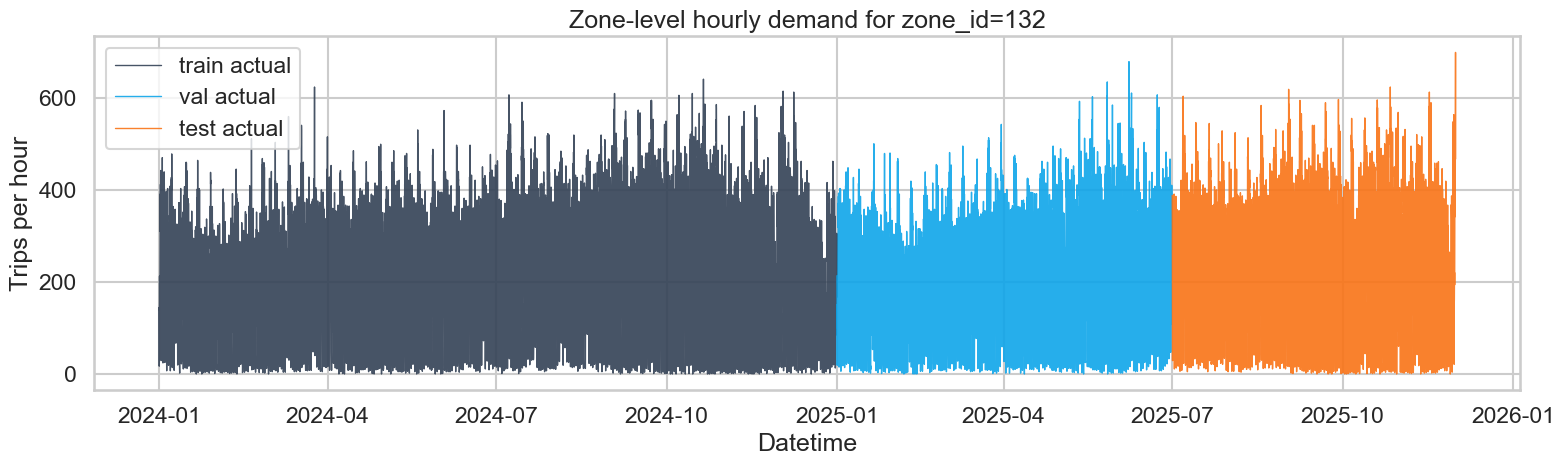

,ds,y,split
16781,2025-11-30 19:00:00,475,test
16782,2025-11-30 20:00:00,484,test
16783,2025-11-30 21:00:00,606,test
16784,2025-11-30 22:00:00,698,test
16785,2025-11-30 23:00:00,467,test


In [36]:
# Step 2Z: Zone-level data view (before zone modeling)
zone_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(zone_train), 'zones': int(zone_train['zone_id'].nunique()), 'start': zone_train['ds'].min(), 'end': zone_train['ds'].max()},
    {'split': 'val', 'rows': len(zone_val), 'zones': int(zone_val['zone_id'].nunique()), 'start': zone_val['ds'].min(), 'end': zone_val['ds'].max()},
    {'split': 'test', 'rows': len(zone_test), 'zones': int(zone_test['zone_id'].nunique()), 'start': zone_test['ds'].min(), 'end': zone_test['ds'].max()},
])
display(zone_summary)

top_zone_counts = (
    zone_train.groupby('zone_id', as_index=False)['y']
    .sum()
    .sort_values('y', ascending=False)
    .rename(columns={'y': 'train_total_demand'})
)
display(top_zone_counts.head(15))

selected_zone_id = int(top_zone_counts.iloc[0]['zone_id'])
zone_view = pd.concat([
    zone_train[zone_train['zone_id'] == selected_zone_id][['ds', 'y']].assign(split='train'),
    zone_val[zone_val['zone_id'] == selected_zone_id][['ds', 'y']].assign(split='val'),
    zone_test[zone_test['zone_id'] == selected_zone_id][['ds', 'y']].assign(split='test'),
], ignore_index=True).sort_values('ds')

plt.figure(figsize=(16, 5))
for split, color in [('train', '#334155'), ('val', '#0ea5e9'), ('test', '#f97316')]:
    part = zone_view[zone_view['split'] == split]
    plt.plot(part['ds'], part['y'], label=f'{split} actual', linewidth=1.0, alpha=0.9, color=color)

plt.title(f'Zone-level hourly demand for zone_id={selected_zone_id}')
plt.xlabel('Datetime')
plt.ylabel('Trips per hour')
plt.legend()
plt.tight_layout()
plt.show()

zone_view.tail()


In [37]:
# Baseline: Seasonal naive (24-hour lag) on validation split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Build baseline predictions: predict each hour using demand from 24 hours earlier
full_city = city_hourly[['ds', 'y']].sort_values('ds').copy()
full_city['baseline_yhat'] = full_city['y'].shift(24)

val_baseline = (
    prophet_city_val[['ds', 'y']]
    .merge(full_city[['ds', 'baseline_yhat']], on='ds', how='left')
    .dropna(subset=['baseline_yhat'])
)

baseline_val_mae = mean_absolute_error(val_baseline['y'], val_baseline['baseline_yhat'])
baseline_val_rmse = mean_squared_error(val_baseline['y'], val_baseline['baseline_yhat']) ** 0.5

# Prophet validation metrics from Step 2
prophet_val_mae = mean_absolute_error(val_pred['y'], val_pred['yhat'])
prophet_val_rmse = mean_squared_error(val_pred['y'], val_pred['yhat']) ** 0.5

val_compare = pd.DataFrame([
    {'model': 'seasonal_naive_lag24', 'split': 'validation', 'mae': float(baseline_val_mae), 'rmse': float(baseline_val_rmse), 'n_rows': int(len(val_baseline))},
    {'model': 'prophet_city_h1h2_time_regressors', 'split': 'validation', 'mae': float(prophet_val_mae), 'rmse': float(prophet_val_rmse), 'n_rows': int(len(val_pred))},
])

val_compare.to_csv(output_dir / 'city_val_model_comparison.csv', index=False)
print(val_compare.to_string(index=False))
val_compare


                            model      split        mae        rmse  n_rows
             seasonal_naive_lag24 validation 718.929312 1052.917679    4343
prophet_city_h1h2_time_regressors validation 903.091376 1132.332995    4343


,model,split,mae,rmse,n_rows
0,seasonal_naive_lag24,validation,718.929312,1052.917679,4343
1,prophet_city_h1h2_time_regressors,validation,903.091376,1132.332995,4343


In [38]:
# Step 2.5: Pre-test setup and model freeze (required before Step 3)
# Purpose: avoid accidental test peeking and lock selection from validation only

if 'val_compare' not in globals():
    raise ValueError('Run Step 2 and baseline validation cell first so val_compare is available.')

validation_ranking = val_compare.sort_values('rmse').reset_index(drop=True)
champion_model = validation_ranking.loc[0, 'model']

frozen_setup = {
    'train_window': '2024-01-01 to 2024-12-31',
    'val_window': '2025-01-01 to 2025-06-30',
    'test_window': '2025-07-01 onward',
    'selection_metric': 'rmse',
    'champion_from_validation': champion_model,
}

RUN_TEST = True
print('Validation ranking')
print(validation_ranking.to_string(index=False))
print()
print('Frozen setup')
print(frozen_setup)
print()
print('Set RUN_TEST = True in this cell after you review frozen setup, then run Step 3.')


Validation ranking
                            model      split        mae        rmse  n_rows
             seasonal_naive_lag24 validation 718.929312 1052.917679    4343
prophet_city_h1h2_time_regressors validation 903.091376 1132.332995    4343

Frozen setup
{'train_window': '2024-01-01 to 2024-12-31', 'val_window': '2025-01-01 to 2025-06-30', 'test_window': '2025-07-01 onward', 'selection_metric': 'rmse', 'champion_from_validation': 'seasonal_naive_lag24'}

Set RUN_TEST = True in this cell after you review frozen setup, then run Step 3.


In [39]:
# Step 3: Final fit and test evaluation (leakage-safe)
# Model selection is based on validation only. Then evaluate once on held-out test.
import numpy as np
# Hard gate to prevent unintended test evaluation
if 'RUN_TEST' not in globals():
    raise ValueError('Run Step 2.5 first.')
if not RUN_TEST:
    raise ValueError('RUN_TEST is False. Review Step 2.5 and set RUN_TEST = True before running Step 3.')


best_model = val_compare.sort_values('rmse').iloc[0]['model']
print('Selected by validation RMSE:', best_model)

test_df = prophet_city_test[['ds', 'y']].copy()

# Baseline test prediction
full_city_for_test = city_hourly[['ds', 'y']].sort_values('ds').copy()
full_city_for_test['baseline_yhat'] = full_city_for_test['y'].shift(24)
test_baseline = (
    test_df.merge(full_city_for_test[['ds', 'baseline_yhat']], on='ds', how='left')
    .dropna(subset=['baseline_yhat'])
)
baseline_test_mae = mean_absolute_error(test_baseline['y'], test_baseline['baseline_yhat'])
baseline_test_rmse = mean_squared_error(test_baseline['y'], test_baseline['baseline_yhat']) ** 0.5
baseline_test_mape = (np.abs((test_baseline['y'] - test_baseline['baseline_yhat']) / test_baseline['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100

# Prophet test prediction: refit on train + val only, then predict test
train_val_df = pd.concat([prophet_city_train[['ds', 'y']], prophet_city_val[['ds', 'y']]], ignore_index=True).sort_values('ds')
train_val_df = add_time_regressors(train_val_df)
test_reg = add_time_regressors(test_df)

m_final = Prophet(
    growth='linear',
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)
m_final.add_country_holidays(country_name='US')
for r in regressors:
    m_final.add_regressor(r)

m_final.fit(train_val_df[['ds', 'y'] + regressors])
test_forecast = m_final.predict(test_reg[['ds'] + regressors])
test_prophet = test_df.merge(test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')
test_prophet[['yhat', 'yhat_lower', 'yhat_upper']] = test_prophet[['yhat', 'yhat_lower', 'yhat_upper']].clip(lower=0)
prophet_test_mae = mean_absolute_error(test_prophet['y'], test_prophet['yhat'])
prophet_test_rmse = mean_squared_error(test_prophet['y'], test_prophet['yhat']) ** 0.5
prophet_test_mape = (np.abs((test_prophet['y'] - test_prophet['yhat']) / test_prophet['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100

test_compare = pd.DataFrame([
    {'model': 'seasonal_naive_lag24', 'split': 'test', 'mae': float(baseline_test_mae), 'rmse': float(baseline_test_rmse), 'mape_pct': float(baseline_test_mape), 'n_rows': int(len(test_baseline))},
    {'model': 'prophet_city_h1h2_time_regressors', 'split': 'test', 'mae': float(prophet_test_mae), 'rmse': float(prophet_test_rmse), 'mape_pct': float(prophet_test_mape), 'n_rows': int(len(test_prophet))},
])

test_compare.to_csv(output_dir / 'city_test_model_comparison.csv', index=False)
test_prophet.to_parquet(output_dir / 'prophet_city_test_predictions.parquet', index=False)
test_baseline.to_parquet(output_dir / 'baseline_city_test_predictions.parquet', index=False)

print(test_compare.to_string(index=False))
test_compare


Selected by validation RMSE: seasonal_naive_lag24


05:44:23 - cmdstanpy - INFO - Chain [1] start processing
05:44:25 - cmdstanpy - INFO - Chain [1] done processing


                            model split        mae       rmse  mape_pct  n_rows
             seasonal_naive_lag24  test 631.844499 928.112877 32.608555    3672
prophet_city_h1h2_time_regressors  test 725.836440 905.256221 41.345110    3672


,model,split,mae,rmse,mape_pct,n_rows
0,seasonal_naive_lag24,test,631.844499,928.112877,32.608555,3672
1,prophet_city_h1h2_time_regressors,test,725.836440,905.256221,41.345110,3672


In [40]:
# Step 4: Segment setup for borough and zone models
zone_lookup_path = repo_root / 'data' / 'external' / 'taxi_zone_lookup.csv'
zone_lookup = pd.read_csv(zone_lookup_path).rename(columns={'LocationID': 'zone_id'})

zone_lookup['is_airport'] = zone_lookup['zone_id'].isin([1, 132, 138]).astype(int)
zone_lookup['is_business'] = ((zone_lookup['Borough'] == 'Manhattan') & (zone_lookup['is_airport'] == 0)).astype(int)
zone_lookup['is_residential'] = (zone_lookup['service_zone'] == 'Boro Zone').astype(int)
zone_lookup['zone_type'] = np.where(zone_lookup['is_airport'] == 1, 'airport', 'non_airport')

zone_train_enriched = zone_train.merge(zone_lookup[['zone_id', 'Borough', 'zone_type', 'is_airport', 'is_business', 'is_residential']], on='zone_id', how='left')
zone_val_enriched = zone_val.merge(zone_lookup[['zone_id', 'Borough', 'zone_type', 'is_airport', 'is_business', 'is_residential']], on='zone_id', how='left')
zone_test_enriched = zone_test.merge(zone_lookup[['zone_id', 'Borough', 'zone_type', 'is_airport', 'is_business', 'is_residential']], on='zone_id', how='left')

def add_time_regs(df):
    out = df.copy()
    out['hour'] = out['ds'].dt.hour
    out['dow'] = out['ds'].dt.dayofweek
    out['is_weekend'] = (out['dow'] >= 5).astype(int)
    out['is_rush_am'] = out['hour'].between(7, 9).astype(int)
    out['is_rush_pm'] = out['hour'].between(17, 19).astype(int)
    out['is_late_night'] = ((out['hour'] >= 22) | (out['hour'] <= 3)).astype(int)
    return out

def fit_predict_prophet(train_seg, pred_seg, static_regressors=None):
    static_regressors = static_regressors or []
    reg_cols = ['is_weekend', 'is_rush_am', 'is_rush_pm', 'is_late_night'] + static_regressors

    tr = add_time_regs(train_seg[['ds', 'y'] + static_regressors]).copy()
    pr = add_time_regs(pred_seg[['ds', 'y'] + static_regressors]).copy()

    m = Prophet(
        growth='linear',
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=0.05,
        seasonality_mode='multiplicative'
    )
    m.add_country_holidays(country_name='US')
    for r in reg_cols:
        m.add_regressor(r)

    m.fit(tr[['ds', 'y'] + reg_cols])
    fc = m.predict(pr[['ds'] + reg_cols])
    out = pr[['ds', 'y']].merge(fc[['ds', 'yhat']], on='ds', how='left')
    out['yhat'] = out['yhat'].clip(lower=0)
    return out, m

def metric_frame(df, model_name, split_name, group_cols=None):
    group_cols = group_cols or []
    work = df.copy()
    if group_cols:
        rows = []
        for k, part in work.groupby(group_cols):
            key = k if isinstance(k, tuple) else (k,)
            row = {c: v for c, v in zip(group_cols, key)}
            row.update({
                'model': model_name,
                'split': split_name,
                'mae': float(mean_absolute_error(part['y'], part['yhat'])),
                'rmse': float(mean_squared_error(part['y'], part['yhat']) ** 0.5),
                'mape_pct': float((np.abs((part['y'] - part['yhat']) / part['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
                'n_rows': int(len(part)),
            })
            rows.append(row)
        return pd.DataFrame(rows)
    return pd.DataFrame([{
        'model': model_name,
        'split': split_name,
        'mae': float(mean_absolute_error(work['y'], work['yhat'])),
        'rmse': float(mean_squared_error(work['y'], work['yhat']) ** 0.5),
        'mape_pct': float((np.abs((work['y'] - work['yhat']) / work['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
        'n_rows': int(len(work)),
    }])

print('Prepared enriched zone splits with borough and zone flags')
zone_lookup.head()


Prepared enriched zone splits with borough and zone flags


,zone_id,Borough,Zone,service_zone,is_airport,is_business,is_residential,zone_type
0,1,EWR,Newark Airport,EWR,1,0,0,airport
1,2,Queens,Jamaica Bay,Boro Zone,0,0,1,non_airport
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone,0,0,1,non_airport
3,4,Manhattan,Alphabet City,Yellow Zone,0,1,0,non_airport
4,5,Staten Island,Arden Heights,Boro Zone,0,0,1,non_airport


In [41]:
# Step 4A: Borough-level Prophet models
borough_train = zone_train_enriched.groupby(['Borough', 'ds'], as_index=False)['y'].sum()
borough_val = zone_val_enriched.groupby(['Borough', 'ds'], as_index=False)['y'].sum()
borough_test = zone_test_enriched.groupby(['Borough', 'ds'], as_index=False)['y'].sum()

borough_models = {}
borough_val_preds = []
borough_test_preds = []

for b in sorted(borough_train['Borough'].dropna().unique()):
    tr = borough_train[borough_train['Borough'] == b][['ds', 'y']].copy()
    va = borough_val[borough_val['Borough'] == b][['ds', 'y']].copy()
    te = borough_test[borough_test['Borough'] == b][['ds', 'y']].copy()

    if tr.empty or va.empty:
        continue

    pred_val, model_b = fit_predict_prophet(tr, va, static_regressors=[])
    pred_val['Borough'] = b
    borough_models[b] = model_b
    borough_val_preds.append(pred_val)

    if not te.empty:
        trv = pd.concat([tr, va], ignore_index=True).sort_values('ds')
        pred_test, _ = fit_predict_prophet(trv, te, static_regressors=[])
        pred_test['Borough'] = b
        borough_test_preds.append(pred_test)

borough_val_pred = pd.concat(borough_val_preds, ignore_index=True) if borough_val_preds else pd.DataFrame(columns=['ds', 'y', 'yhat', 'Borough'])
borough_test_pred = pd.concat(borough_test_preds, ignore_index=True) if borough_test_preds else pd.DataFrame(columns=['ds', 'y', 'yhat', 'Borough'])

borough_val_metrics = metric_frame(borough_val_pred, 'prophet_borough', 'validation')
borough_test_metrics = metric_frame(borough_test_pred, 'prophet_borough', 'test')

borough_val_pred.to_parquet(output_dir / 'prophet_borough_val_predictions.parquet', index=False)
borough_test_pred.to_parquet(output_dir / 'prophet_borough_test_predictions.parquet', index=False)
pd.concat([borough_val_metrics, borough_test_metrics], ignore_index=True).to_csv(output_dir / 'prophet_borough_metrics.csv', index=False)

print('Borough models trained:', len(borough_models))
pd.concat([borough_val_metrics, borough_test_metrics], ignore_index=True)


05:44:26 - cmdstanpy - INFO - Chain [1] start processing
05:44:27 - cmdstanpy - INFO - Chain [1] done processing
05:44:28 - cmdstanpy - INFO - Chain [1] start processing
05:44:29 - cmdstanpy - INFO - Chain [1] done processing
05:44:30 - cmdstanpy - INFO - Chain [1] start processing
05:44:32 - cmdstanpy - INFO - Chain [1] done processing
05:44:33 - cmdstanpy - INFO - Chain [1] start processing
05:44:36 - cmdstanpy - INFO - Chain [1] done processing
05:44:36 - cmdstanpy - INFO - Chain [1] start processing
05:44:37 - cmdstanpy - INFO - Chain [1] done processing
05:44:37 - cmdstanpy - INFO - Chain [1] start processing
05:44:38 - cmdstanpy - INFO - Chain [1] done processing
05:44:38 - cmdstanpy - INFO - Chain [1] start processing
05:44:40 - cmdstanpy - INFO - Chain [1] done processing
05:44:41 - cmdstanpy - INFO - Chain [1] start processing
05:44:43 - cmdstanpy - INFO - Chain [1] done processing
05:44:44 - cmdstanpy - INFO - Chain [1] start processing
05:44:46 - cmdstanpy - INFO - Chain [1]

Borough models trained: 7


,model,split,mae,rmse,mape_pct,n_rows
0,prophet_borough,validation,192.190076,433.850270,64.125580,22976
1,prophet_borough,test,151.968310,380.556334,52.072079,19866


In [42]:
# Step 4A2: Borough baseline (seasonal naive lag 24)
from sklearn.metrics import mean_absolute_error, mean_squared_error

borough_full = (
    zone_hourly.merge(zone_lookup[['zone_id', 'Borough']], on='zone_id', how='left')
    .groupby(['Borough', 'ds'], as_index=False)['y']
    .sum()
    .sort_values(['Borough', 'ds'])
)
borough_full['yhat_baseline'] = borough_full.groupby('Borough')['y'].shift(24)

borough_val_base = (
    borough_val[['Borough', 'ds', 'y']]
    .merge(borough_full[['Borough', 'ds', 'yhat_baseline']], on=['Borough', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)
borough_test_base = (
    borough_test[['Borough', 'ds', 'y']]
    .merge(borough_full[['Borough', 'ds', 'yhat_baseline']], on=['Borough', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)

def baseline_metrics(df, split_name):
    return pd.DataFrame([{
        'model': 'seasonal_naive_borough_lag24',
        'split': split_name,
        'mae': float(mean_absolute_error(df['y'], df['yhat_baseline'])),
        'rmse': float(mean_squared_error(df['y'], df['yhat_baseline']) ** 0.5),
        'mape_pct': float((np.abs((df['y'] - df['yhat_baseline']) / df['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
        'n_rows': int(len(df)),
    }])

borough_baseline_metrics = pd.concat([
    baseline_metrics(borough_val_base, 'validation'),
    baseline_metrics(borough_test_base, 'test'),
], ignore_index=True)

borough_val_base.to_parquet(output_dir / 'baseline_borough_val_predictions.parquet', index=False)
borough_test_base.to_parquet(output_dir / 'baseline_borough_test_predictions.parquet', index=False)
borough_baseline_metrics.to_csv(output_dir / 'baseline_borough_metrics.csv', index=False)

display(borough_baseline_metrics)


,model,split,mae,rmse,mape_pct,n_rows
0,seasonal_naive_borough_lag24,validation,158.716617,472.25540,63.040295,22976
1,seasonal_naive_borough_lag24,test,140.006645,408.82445,58.413773,19866


In [43]:
# Step 4B: Top-N zone Prophet models by train volume
top_n = 30
min_train_rows = 24 * 90

zone_rank = zone_train_enriched.groupby('zone_id', as_index=False)['y'].sum().sort_values('y', ascending=False)
candidate_zones = zone_rank['zone_id'].tolist()

top_zone_models = {}
top_zone_ids = []
top_zone_val_preds = []
top_zone_test_preds = []

for z in candidate_zones:
    if len(top_zone_ids) >= top_n:
        break

    tr = zone_train_enriched[zone_train_enriched['zone_id'] == z][['ds', 'y', 'is_airport', 'is_business', 'is_residential']].copy()
    va = zone_val_enriched[zone_val_enriched['zone_id'] == z][['ds', 'y', 'is_airport', 'is_business', 'is_residential']].copy()
    te = zone_test_enriched[zone_test_enriched['zone_id'] == z][['ds', 'y', 'is_airport', 'is_business', 'is_residential']].copy()

    if len(tr) < min_train_rows or va.empty:
        continue

    pred_val, model_z = fit_predict_prophet(tr, va, static_regressors=['is_airport', 'is_business', 'is_residential'])
    pred_val['zone_id'] = z
    top_zone_val_preds.append(pred_val)
    top_zone_models[z] = model_z
    top_zone_ids.append(z)

    if not te.empty:
        trv = pd.concat([tr, va], ignore_index=True).sort_values('ds')
        pred_test, _ = fit_predict_prophet(trv, te, static_regressors=['is_airport', 'is_business', 'is_residential'])
        pred_test['zone_id'] = z
        top_zone_test_preds.append(pred_test)

top_zone_val_pred = pd.concat(top_zone_val_preds, ignore_index=True) if top_zone_val_preds else pd.DataFrame(columns=['ds', 'y', 'yhat', 'zone_id'])
top_zone_test_pred = pd.concat(top_zone_test_preds, ignore_index=True) if top_zone_test_preds else pd.DataFrame(columns=['ds', 'y', 'yhat', 'zone_id'])

top_zone_val_pred.to_parquet(output_dir / 'prophet_top_zone_val_predictions.parquet', index=False)
top_zone_test_pred.to_parquet(output_dir / 'prophet_top_zone_test_predictions.parquet', index=False)

print('Top-zone models trained:', len(top_zone_ids))
print('Sample zone IDs:', top_zone_ids[:10])
top_zone_val_pred.head()


05:44:56 - cmdstanpy - INFO - Chain [1] start processing
05:45:04 - cmdstanpy - INFO - Chain [1] done processing
05:45:05 - cmdstanpy - INFO - Chain [1] start processing
05:45:12 - cmdstanpy - INFO - Chain [1] done processing
05:45:13 - cmdstanpy - INFO - Chain [1] start processing
05:45:20 - cmdstanpy - INFO - Chain [1] done processing
05:45:21 - cmdstanpy - INFO - Chain [1] start processing
05:45:32 - cmdstanpy - INFO - Chain [1] done processing
05:45:33 - cmdstanpy - INFO - Chain [1] start processing
05:45:36 - cmdstanpy - INFO - Chain [1] done processing
05:45:37 - cmdstanpy - INFO - Chain [1] start processing
05:45:42 - cmdstanpy - INFO - Chain [1] done processing
05:45:43 - cmdstanpy - INFO - Chain [1] start processing
05:45:47 - cmdstanpy - INFO - Chain [1] done processing
05:45:48 - cmdstanpy - INFO - Chain [1] start processing
05:45:55 - cmdstanpy - INFO - Chain [1] done processing
05:45:56 - cmdstanpy - INFO - Chain [1] start processing
05:45:58 - cmdstanpy - INFO - Chain [1]

Top-zone models trained: 30
Sample zone IDs: [132, 237, 161, 236, 162, 186, 230, 138, 142, 163]


,ds,y,yhat,zone_id
0,2025-01-01 00:00:00,214,135.866370,132
1,2025-01-01 01:00:00,67,53.711275,132
2,2025-01-01 02:00:00,63,0.000000,132
3,2025-01-01 03:00:00,20,0.000000,132
4,2025-01-01 04:00:00,23,0.000000,132


In [44]:
# Step 4B2: Zone baselines (seasonal naive lag 24)
from sklearn.metrics import mean_absolute_error, mean_squared_error

zone_full = zone_hourly[['zone_id', 'ds', 'y']].sort_values(['zone_id', 'ds']).copy()
zone_full['yhat_baseline'] = zone_full.groupby('zone_id')['y'].shift(24)

top_zone_set = set(top_zone_ids) if 'top_zone_ids' in globals() else set()
zone_val_top_base = (
    zone_val[zone_val['zone_id'].isin(top_zone_set)][['zone_id', 'ds', 'y']]
    .merge(zone_full[['zone_id', 'ds', 'yhat_baseline']], on=['zone_id', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)
zone_test_top_base = (
    zone_test[zone_test['zone_id'].isin(top_zone_set)][['zone_id', 'ds', 'y']]
    .merge(zone_full[['zone_id', 'ds', 'yhat_baseline']], on=['zone_id', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)
zone_val_all_base = (
    zone_val[['zone_id', 'ds', 'y']]
    .merge(zone_full[['zone_id', 'ds', 'yhat_baseline']], on=['zone_id', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)
zone_test_all_base = (
    zone_test[['zone_id', 'ds', 'y']]
    .merge(zone_full[['zone_id', 'ds', 'yhat_baseline']], on=['zone_id', 'ds'], how='left')
    .dropna(subset=['yhat_baseline'])
)

def zone_baseline_metrics(df, split_name, model_name):
    return pd.DataFrame([{
        'model': model_name,
        'split': split_name,
        'mae': float(mean_absolute_error(df['y'], df['yhat_baseline'])),
        'rmse': float(mean_squared_error(df['y'], df['yhat_baseline']) ** 0.5),
        'mape_pct': float((np.abs((df['y'] - df['yhat_baseline']) / df['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
        'n_rows': int(len(df)),
    }])

zone_top_base_metrics = pd.concat([
    zone_baseline_metrics(zone_val_top_base, 'validation', 'seasonal_naive_top_zone_lag24'),
    zone_baseline_metrics(zone_test_top_base, 'test', 'seasonal_naive_top_zone_lag24'),
], ignore_index=True)
zone_all_base_metrics = pd.concat([
    zone_baseline_metrics(zone_val_all_base, 'validation', 'seasonal_naive_all_zone_lag24'),
    zone_baseline_metrics(zone_test_all_base, 'test', 'seasonal_naive_all_zone_lag24'),
], ignore_index=True)

zone_top_base_metrics.to_csv(output_dir / 'baseline_top_zone_metrics.csv', index=False)
zone_all_base_metrics.to_csv(output_dir / 'baseline_all_zone_metrics.csv', index=False)
zone_val_top_base.to_parquet(output_dir / 'baseline_top_zone_val_predictions.parquet', index=False)
zone_test_top_base.to_parquet(output_dir / 'baseline_top_zone_test_predictions.parquet', index=False)
zone_val_all_base.to_parquet(output_dir / 'baseline_all_zone_val_predictions.parquet', index=False)
zone_test_all_base.to_parquet(output_dir / 'baseline_all_zone_test_predictions.parquet', index=False)

display(pd.concat([zone_top_base_metrics, zone_all_base_metrics], ignore_index=True))


,model,split,mae,rmse,mape_pct,n_rows
0,seasonal_naive_top_zone_lag24,validation,32.236686,53.433184,79.663309,129078
1,seasonal_naive_top_zone_lag24,test,29.505788,49.844164,76.798127,109190
2,seasonal_naive_all_zone_lag24,validation,12.057049,29.717916,81.620809,467844
3,seasonal_naive_all_zone_lag24,test,10.069253,26.046791,82.809155,451360


In [45]:
# Step 4C: Fallback hierarchy and zone-type metrics
# Hierarchy: top-zone model -> borough model -> city model

if 'test_prophet' not in globals():
    raise ValueError('Run Step 3 first so city-level test predictions are available in test_prophet')

city_test_pred = test_prophet[['ds', 'yhat']].copy().rename(columns={'yhat': 'yhat_city'})

# Build validation fallback predictions
val_base = zone_val_enriched[['zone_id', 'Borough', 'zone_type', 'ds', 'y']].copy()
val_base = val_base.merge(top_zone_val_pred[['zone_id', 'ds', 'yhat']].rename(columns={'yhat': 'yhat_zone'}), on=['zone_id', 'ds'], how='left')
val_base = val_base.merge(borough_val_pred[['Borough', 'ds', 'yhat']].rename(columns={'yhat': 'yhat_borough'}), on=['Borough', 'ds'], how='left')
val_base = val_base.merge(val_pred[['ds', 'yhat']].rename(columns={'yhat': 'yhat_city'}), on='ds', how='left')
val_base['yhat'] = val_base['yhat_zone'].combine_first(val_base['yhat_borough']).combine_first(val_base['yhat_city'])
val_base['yhat'] = val_base['yhat'].clip(lower=0)
val_base['source_model'] = np.where(val_base['yhat_zone'].notna(), 'zone', np.where(val_base['yhat_borough'].notna(), 'borough', 'city'))

# Build test fallback predictions
test_base = zone_test_enriched[['zone_id', 'Borough', 'zone_type', 'ds', 'y']].copy()
test_base = test_base.merge(top_zone_test_pred[['zone_id', 'ds', 'yhat']].rename(columns={'yhat': 'yhat_zone'}), on=['zone_id', 'ds'], how='left')
test_base = test_base.merge(borough_test_pred[['Borough', 'ds', 'yhat']].rename(columns={'yhat': 'yhat_borough'}), on=['Borough', 'ds'], how='left')
test_base = test_base.merge(city_test_pred, on='ds', how='left')
test_base['yhat'] = test_base['yhat_zone'].combine_first(test_base['yhat_borough']).combine_first(test_base['yhat_city'])
test_base['yhat'] = test_base['yhat'].clip(lower=0)
test_base['source_model'] = np.where(test_base['yhat_zone'].notna(), 'zone', np.where(test_base['yhat_borough'].notna(), 'borough', 'city'))

val_overall = metric_frame(val_base[['y', 'yhat']], 'hierarchical_prophet', 'validation')
test_overall = metric_frame(test_base[['y', 'yhat']], 'hierarchical_prophet', 'test')
val_by_zone_type = metric_frame(val_base[['zone_type', 'y', 'yhat']], 'hierarchical_prophet', 'validation', group_cols=['zone_type'])
test_by_zone_type = metric_frame(test_base[['zone_type', 'y', 'yhat']], 'hierarchical_prophet', 'test', group_cols=['zone_type'])

model_source_mix_val = val_base['source_model'].value_counts(normalize=True).rename('pct').reset_index().rename(columns={'index': 'source_model'})
model_source_mix_test = test_base['source_model'].value_counts(normalize=True).rename('pct').reset_index().rename(columns={'index': 'source_model'})

val_base.to_parquet(output_dir / 'hierarchical_zone_val_predictions.parquet', index=False)
test_base.to_parquet(output_dir / 'hierarchical_zone_test_predictions.parquet', index=False)
pd.concat([val_overall, test_overall, val_by_zone_type, test_by_zone_type], ignore_index=True).to_csv(output_dir / 'hierarchical_prophet_metrics.csv', index=False)
model_source_mix_val.to_csv(output_dir / 'hierarchical_source_mix_val.csv', index=False)
model_source_mix_test.to_csv(output_dir / 'hierarchical_source_mix_test.csv', index=False)

print('Validation and test hierarchical metrics saved')
pd.concat([val_overall, test_overall, val_by_zone_type, test_by_zone_type], ignore_index=True)


Validation and test hierarchical metrics saved


,model,split,mae,rmse,mape_pct,n_rows,zone_type
0,hierarchical_prophet,validation,1060.928668,2146.858538,22589.637169,467895,NaN
1,hierarchical_prophet,test,1038.658915,2073.392117,25832.300329,451403,NaN
2,hierarchical_prophet,validation,106.345466,158.489499,81.382127,9844,airport
3,hierarchical_prophet,validation,1081.443669,2169.680637,23073.363354,458051,non_airport
4,hierarchical_prophet,test,40.347064,60.564295,93.025254,8620,airport
5,hierarchical_prophet,test,1058.093825,2093.459947,26333.386755,442783,non_airport


In [46]:
# Step 4D: Rolling time-based backtests (no random split)
# Runs on city and borough segments for reproducible temporal validation

def rolling_backtest(segment_df, segment_id='city', horizon_hours=24*14, n_folds=4):
    segment_df = segment_df[['ds', 'y']].sort_values('ds').drop_duplicates('ds').reset_index(drop=True)
    cutoffs = pd.date_range(start=segment_df['ds'].min() + pd.Timedelta(days=180), end=segment_df['ds'].max() - pd.Timedelta(hours=horizon_hours), periods=n_folds)

    rows = []
    for cutoff in cutoffs:
        train_fold = segment_df[segment_df['ds'] < cutoff].copy()
        test_fold = segment_df[(segment_df['ds'] >= cutoff) & (segment_df['ds'] < cutoff + pd.Timedelta(hours=horizon_hours))].copy()
        if len(train_fold) < 24 * 90 or test_fold.empty:
            continue

        pred_fold, _ = fit_predict_prophet(train_fold, test_fold, static_regressors=[])
        rows.append({
            'segment_id': segment_id,
            'cutoff': cutoff,
            'mae': float(mean_absolute_error(pred_fold['y'], pred_fold['yhat'])),
            'rmse': float(mean_squared_error(pred_fold['y'], pred_fold['yhat']) ** 0.5),
            'mape_pct': float((np.abs((pred_fold['y'] - pred_fold['yhat']) / pred_fold['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
            'n_rows': int(len(pred_fold)),
        })

    return pd.DataFrame(rows)

city_series_for_bt = pd.concat([prophet_city_train[['ds', 'y']], prophet_city_val[['ds', 'y']]], ignore_index=True)
city_bt = rolling_backtest(city_series_for_bt, segment_id='city', horizon_hours=24*14, n_folds=4)

borough_bt_frames = []
for b in sorted(borough_train['Borough'].dropna().unique()):
    seg = borough_train[borough_train['Borough'] == b][['ds', 'y']].copy()
    if len(seg) < 24 * 120:
        continue
    bt = rolling_backtest(seg, segment_id=f'borough:{b}', horizon_hours=24*14, n_folds=3)
    borough_bt_frames.append(bt)

borough_bt = pd.concat(borough_bt_frames, ignore_index=True) if borough_bt_frames else pd.DataFrame(columns=['segment_id', 'cutoff', 'mae', 'rmse', 'mape_pct', 'n_rows'])
rolling_bt = pd.concat([city_bt, borough_bt], ignore_index=True)
rolling_bt.to_csv(output_dir / 'rolling_backtest_metrics.csv', index=False)
rolling_bt.head()


05:51:15 - cmdstanpy - INFO - Chain [1] start processing
05:51:16 - cmdstanpy - INFO - Chain [1] done processing
05:51:16 - cmdstanpy - INFO - Chain [1] start processing
05:51:18 - cmdstanpy - INFO - Chain [1] done processing
05:51:19 - cmdstanpy - INFO - Chain [1] start processing
05:51:20 - cmdstanpy - INFO - Chain [1] done processing
05:51:21 - cmdstanpy - INFO - Chain [1] start processing
05:51:22 - cmdstanpy - INFO - Chain [1] done processing
05:51:22 - cmdstanpy - INFO - Chain [1] start processing
05:51:23 - cmdstanpy - INFO - Chain [1] done processing
05:51:23 - cmdstanpy - INFO - Chain [1] start processing
05:51:23 - cmdstanpy - INFO - Chain [1] done processing
05:51:24 - cmdstanpy - INFO - Chain [1] start processing
05:51:25 - cmdstanpy - INFO - Chain [1] done processing
05:51:25 - cmdstanpy - INFO - Chain [1] start processing
05:51:25 - cmdstanpy - INFO - Chain [1] done processing
05:51:26 - cmdstanpy - INFO - Chain [1] start processing
05:51:26 - cmdstanpy - INFO - Chain [1]

,segment_id,cutoff,mae,rmse,mape_pct,n_rows
0,city,2024-06-29 00:00:00,2048.101205,2297.174944,125.850239,336
1,city,2024-10-24 15:40:00,2351.726847,2998.557822,61.917551,336
2,city,2025-02-19 07:20:00,697.749306,903.416428,48.464636,336
3,city,2025-06-16 23:00:00,673.926543,829.087992,34.944348,336
4,borough:Bronx,2024-06-29 00:00:00,3.990046,4.850856,114.469431,314


In [47]:
# Step 4E: Deployment hooks (retrain cadence and drift monitor scaffolding)
deployment_plan = {
    'model_family': 'Prophet hierarchical (zone -> borough -> city)',
    'retrain_cadence': 'weekly for top-zones, monthly for borough/city',
    'serving_priority': ['zone', 'borough', 'city'],
    'monitoring': {
        'metrics': ['mae', 'rmse', 'mape_pct'],
        'slices': ['zone_id', 'Borough', 'zone_type', 'hour'],
        'alert_rule': 'alert if weekly MAE increases > 20 percent vs trailing 4-week mean'
    }
}

# Drift report from hierarchical test predictions (template for production scoring logs)
if (output_dir / 'hierarchical_zone_test_predictions.parquet').exists():
    drift_base = pd.read_parquet(output_dir / 'hierarchical_zone_test_predictions.parquet')
    drift_base['abs_err'] = (drift_base['y'] - drift_base['yhat']).abs()
    drift_base['hour'] = drift_base['ds'].dt.hour

    drift_weekly = (
        drift_base.assign(week=drift_base['ds'].dt.to_period('W').astype(str))
        .groupby(['week', 'zone_type', 'hour'], as_index=False)['abs_err']
        .mean()
        .rename(columns={'abs_err': 'mae'})
    )
    drift_weekly.to_csv(output_dir / 'drift_weekly_zone_hour_mae.csv', index=False)

print(deployment_plan)
print('Saved deployment/drift artifacts under', output_dir)


{'model_family': 'Prophet hierarchical (zone -> borough -> city)', 'retrain_cadence': 'weekly for top-zones, monthly for borough/city', 'serving_priority': ['zone', 'borough', 'city'], 'monitoring': {'metrics': ['mae', 'rmse', 'mape_pct'], 'slices': ['zone_id', 'Borough', 'zone_type', 'hour'], 'alert_rule': 'alert if weekly MAE increases > 20 percent vs trailing 4-week mean'}}
Saved deployment/drift artifacts under /Users/racheldong/Documents/GitHub/nyc-mobility-analysis/data/interim/prophet


In [48]:
import pandas as pd
from pathlib import Path

p = Path("/Users/racheldong/Documents/GitHub/nyc-mobility-analysis/data/interim/prophet/prophet_top_zone_test_predictions.parquet")
df = pd.read_parquet(p)
print(df.head())
print(df.shape)


                   ds    y        yhat  zone_id
0 2025-07-01 00:00:00  388  268.799245      132
1 2025-07-01 01:00:00  338  152.808799      132
2 2025-07-01 02:00:00  139   60.750378      132
3 2025-07-01 03:00:00   59   27.153190      132
4 2025-07-01 04:00:00   30   27.370465      132
(109190, 4)


In [61]:
# Step 5: Visualization setup
import matplotlib.pyplot as plt
import seaborn as sns

# Yellow + black brand style
sns.set_theme(context='talk', style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#0b0b0b',
    'axes.facecolor': '#111111',
    'axes.edgecolor': '#facc15',
    'axes.labelcolor': '#fde68a',
    'axes.titlecolor': '#fde047',
    'xtick.color': '#fef3c7',
    'ytick.color': '#fef3c7',
    'grid.color': '#3a3a3a',
    'text.color': '#fde68a',
    'legend.facecolor': '#111111',
    'legend.edgecolor': '#facc15',
})

BRAND = {
    'yellow': '#facc15',
    'gold': '#fde047',
    'amber': '#f59e0b',
    'ink': '#0b0b0b',
    'slate': '#1f1f1f',
    'light': '#fef3c7',
    'blue': '#38bdf8',
    'orange': '#fb923c',
}

OMBR_YELLOW = ['#fef9c3', '#fde047', '#facc15', '#eab308', '#ca8a04']
OMBR_MIX = ['#fde047', '#f59e0b', '#f97316', '#fb7185', '#38bdf8']

plot_dir = output_dir / 'plots'
plot_dir.mkdir(parents=True, exist_ok=True)
print('Plot output directory:', plot_dir)

def stylize_ax(ax, title):
    ax.set_title(title, pad=12, fontweight='bold')
    ax.set_facecolor(BRAND['slate'])
    for spine in ax.spines.values():
        spine.set_color(BRAND['yellow'])
        spine.set_alpha(0.6)

def ombre_fill(ax, x, y, color):
    # Soft layered fill to mimic ombre glow
    for alpha, shrink in [(0.18, 1.00), (0.12, 0.95), (0.08, 0.90), (0.05, 0.85)]:
        ax.fill_between(x, y * shrink, y, color=color, alpha=alpha)


Plot output directory: /Users/racheldong/Documents/GitHub/nyc-mobility-analysis/data/interim/prophet/plots


/var/folders/rl/2kbvhn0n0mqct77jtc2_t8740000gn/T/ipykernel_96253/2372518916.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_test_cmp, x='model', y='mae', ax=axes[0], palette='Blues_r')
/var/folders/rl/2kbvhn0n0mqct77jtc2_t8740000gn/T/ipykernel_96253/2372518916.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_test_cmp, x='model', y='rmse', ax=axes[1], palette='Greens_r')
/var/folders/rl/2kbvhn0n0mqct77jtc2_t8740000gn/T/ipykernel_96253/2372518916.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_test_cm

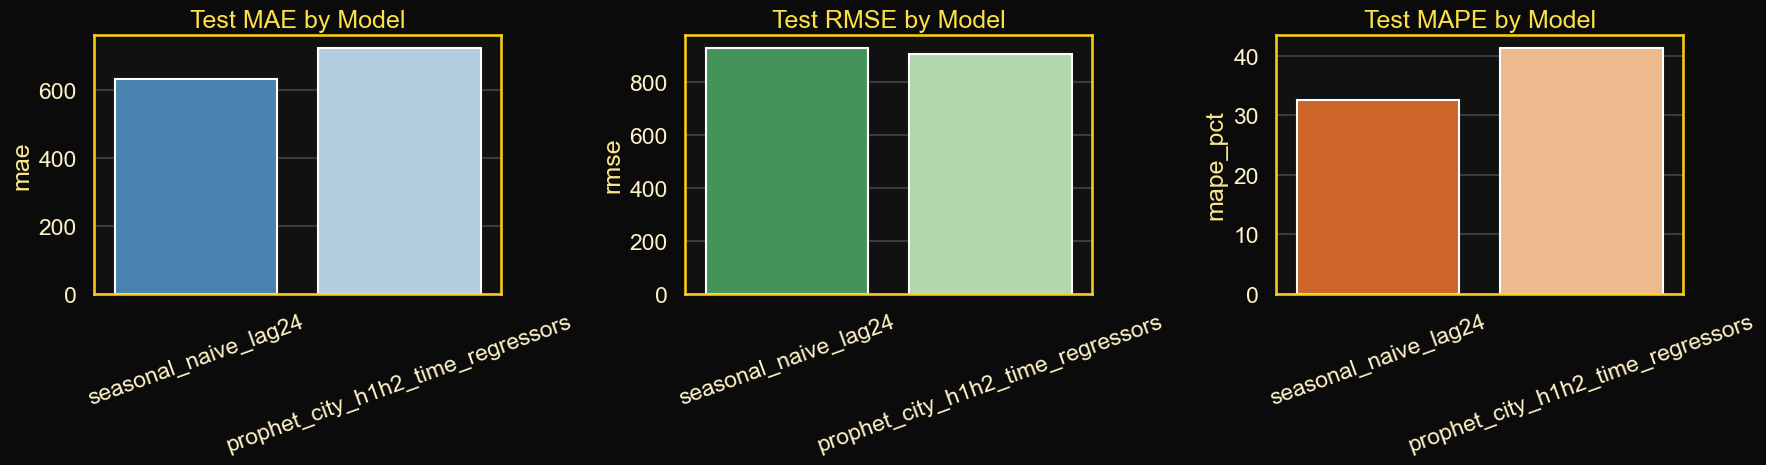

,model,split,mae,rmse,mape_pct,n_rows
0,seasonal_naive_lag24,test,631.844499,928.112877,32.608555,3672
1,prophet_city_h1h2_time_regressors,test,725.836440,905.256221,41.345110,3672


In [62]:
# Step 5A: City test model comparison plots
city_test_cmp = pd.read_csv(output_dir / 'city_test_model_comparison.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=city_test_cmp, x='model', y='mae', ax=axes[0], palette='Blues_r')
axes[0].set_title('Test MAE by Model')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=city_test_cmp, x='model', y='rmse', ax=axes[1], palette='Greens_r')
axes[1].set_title('Test RMSE by Model')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=city_test_cmp, x='model', y='mape_pct', ax=axes[2], palette='Oranges_r')
axes[2].set_title('Test MAPE by Model')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(plot_dir / 'city_test_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
city_test_cmp


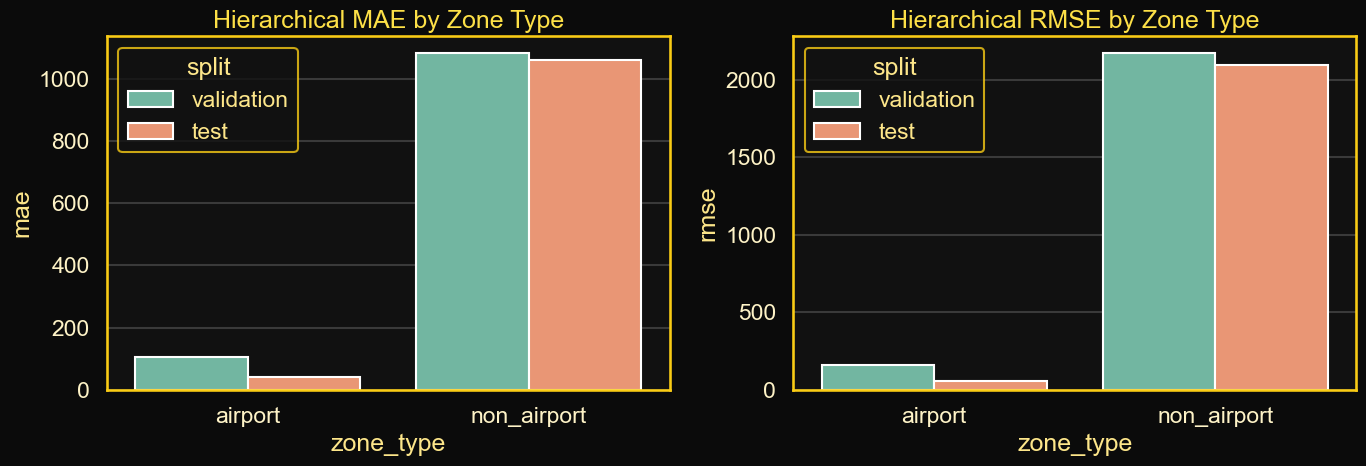

,model,split,mae,rmse,mape_pct,n_rows,zone_type
2,hierarchical_prophet,validation,106.345466,158.489499,81.382127,9844,airport
3,hierarchical_prophet,validation,1081.443669,2169.680637,23073.363354,458051,non_airport
4,hierarchical_prophet,test,40.347064,60.564295,93.025254,8620,airport
5,hierarchical_prophet,test,1058.093825,2093.459947,26333.386755,442783,non_airport


In [63]:
# Step 5B: Hierarchical metrics by split and zone type
hier_metrics = pd.read_csv(output_dir / 'hierarchical_prophet_metrics.csv')
zone_slice = hier_metrics[hier_metrics['zone_type'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=zone_slice, x='zone_type', y='mae', hue='split', ax=axes[0], palette='Set2')
axes[0].set_title('Hierarchical MAE by Zone Type')

sns.barplot(data=zone_slice, x='zone_type', y='rmse', hue='split', ax=axes[1], palette='Set2')
axes[1].set_title('Hierarchical RMSE by Zone Type')

plt.tight_layout()
plt.savefig(plot_dir / 'hierarchical_zone_type_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
zone_slice


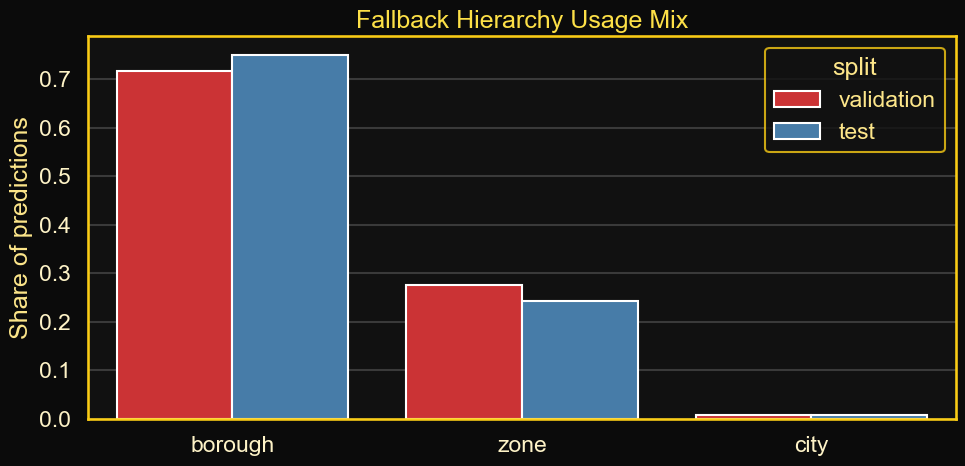

,source_model,pct,split
0,borough,0.716896,validation
1,zone,0.275870,validation
2,city,0.007235,validation
3,borough,0.751322,test
4,zone,0.241890,test
5,city,0.006788,test


In [64]:
# Step 5C: Fallback source mix visualization
source_mix_val = pd.read_csv(output_dir / 'hierarchical_source_mix_val.csv')
source_mix_test = pd.read_csv(output_dir / 'hierarchical_source_mix_test.csv')
source_mix_val['split'] = 'validation'
source_mix_test['split'] = 'test'
source_mix = pd.concat([source_mix_val, source_mix_test], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=source_mix, x='source_model', y='pct', hue='split', palette='Set1')
plt.title('Fallback Hierarchy Usage Mix')
plt.ylabel('Share of predictions')
plt.xlabel('')
plt.tight_layout()
plt.savefig(plot_dir / 'fallback_source_mix.png', dpi=150, bbox_inches='tight')
plt.show()
source_mix


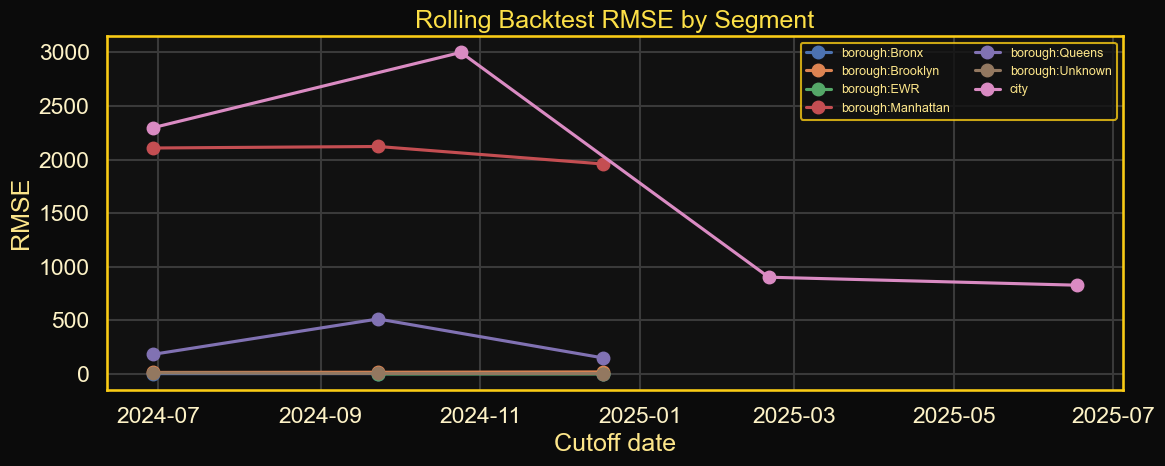

,segment_id,cutoff,mae,rmse,mape_pct,n_rows
0,city,2024-06-29 00:00:00,2048.101205,2297.174944,125.850239,336
1,city,2024-10-24 15:40:00,2351.726847,2998.557822,61.917551,336
2,city,2025-02-19 07:20:00,697.749306,903.416428,48.464636,336
3,city,2025-06-16 23:00:00,673.926543,829.087992,34.944348,336
4,borough:Bronx,2024-06-29 00:00:00,3.990046,4.850856,114.469431,314


In [65]:
# Step 5D: Rolling backtest trend visualization
bt = pd.read_csv(output_dir / 'rolling_backtest_metrics.csv')
bt['cutoff'] = pd.to_datetime(bt['cutoff'])

plt.figure(figsize=(12, 5))
for sid, part in bt.groupby('segment_id'):
    plt.plot(part['cutoff'], part['rmse'], marker='o', label=sid)
plt.title('Rolling Backtest RMSE by Segment')
plt.xlabel('Cutoff date')
plt.ylabel('RMSE')
plt.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(plot_dir / 'rolling_backtest_rmse_trend.png', dpi=150, bbox_inches='tight')
plt.show()
bt.head()


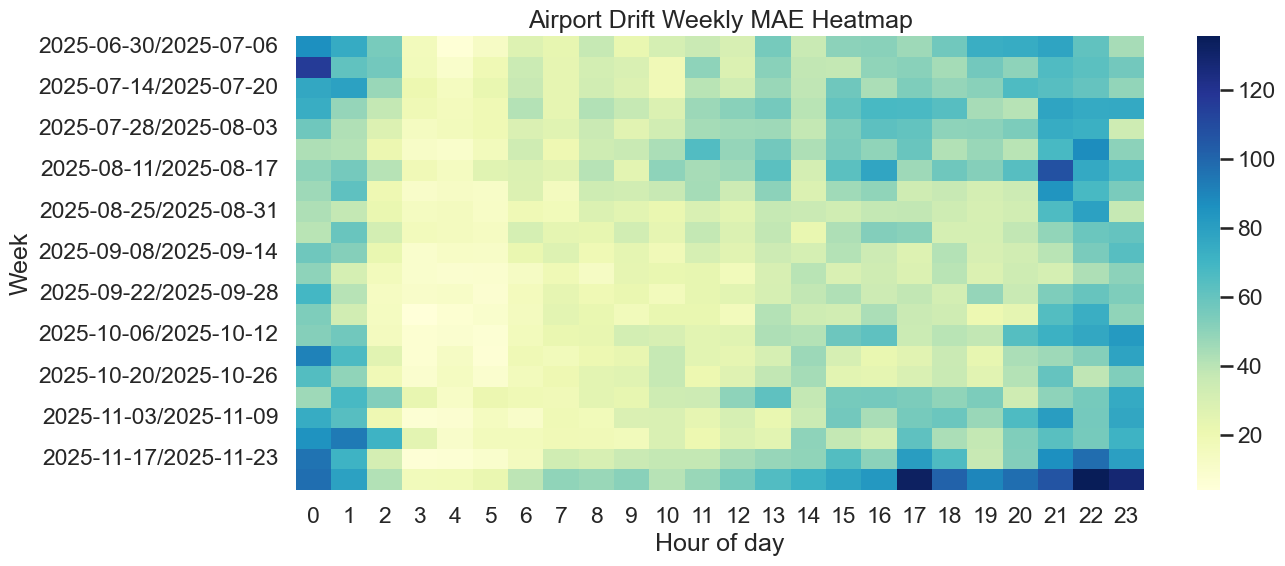

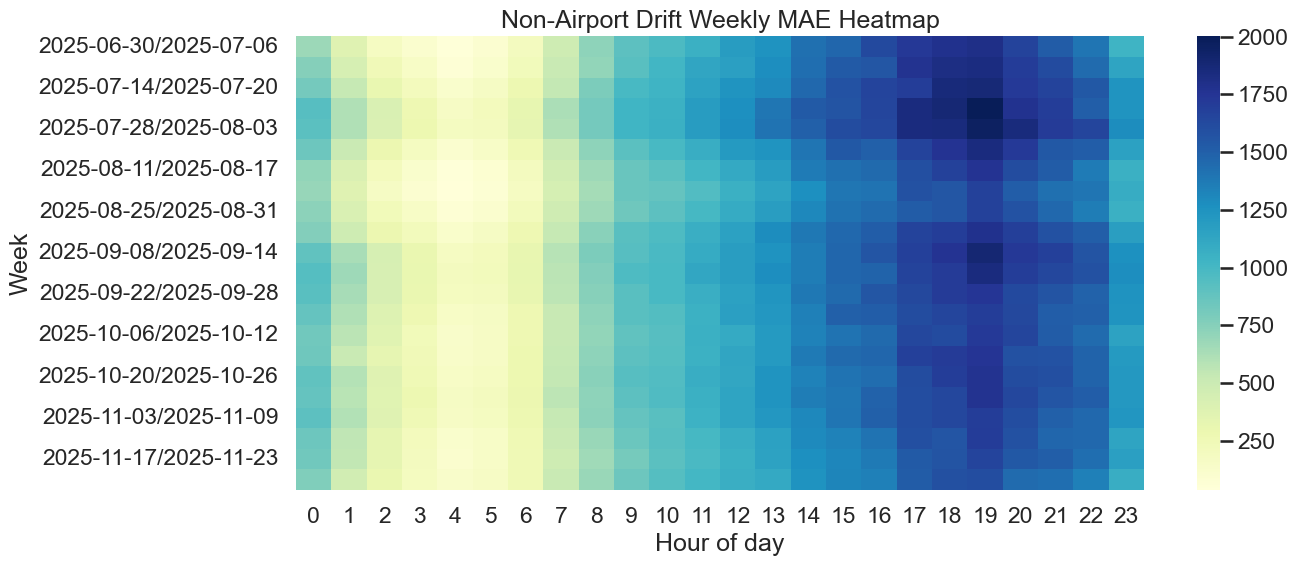

In [54]:
# Step 5E: Drift heatmap by hour and week
drift = pd.read_csv(output_dir / 'drift_weekly_zone_hour_mae.csv')
drift_air = drift[drift['zone_type'] == 'airport'].copy()
drift_non = drift[drift['zone_type'] == 'non_airport'].copy()

def plot_heatmap(df, title, file_name):
    if df.empty:
        print('No data for', title)
        return
    pivot = df.pivot_table(index='week', columns='hour', values='mae', aggfunc='mean')
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, cmap='YlGnBu')
    plt.title(title)
    plt.xlabel('Hour of day')
    plt.ylabel('Week')
    plt.tight_layout()
    plt.savefig(plot_dir / file_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_heatmap(drift_air, 'Airport Drift Weekly MAE Heatmap', 'drift_airport_heatmap.png')
plot_heatmap(drift_non, 'Non-Airport Drift Weekly MAE Heatmap', 'drift_non_airport_heatmap.png')


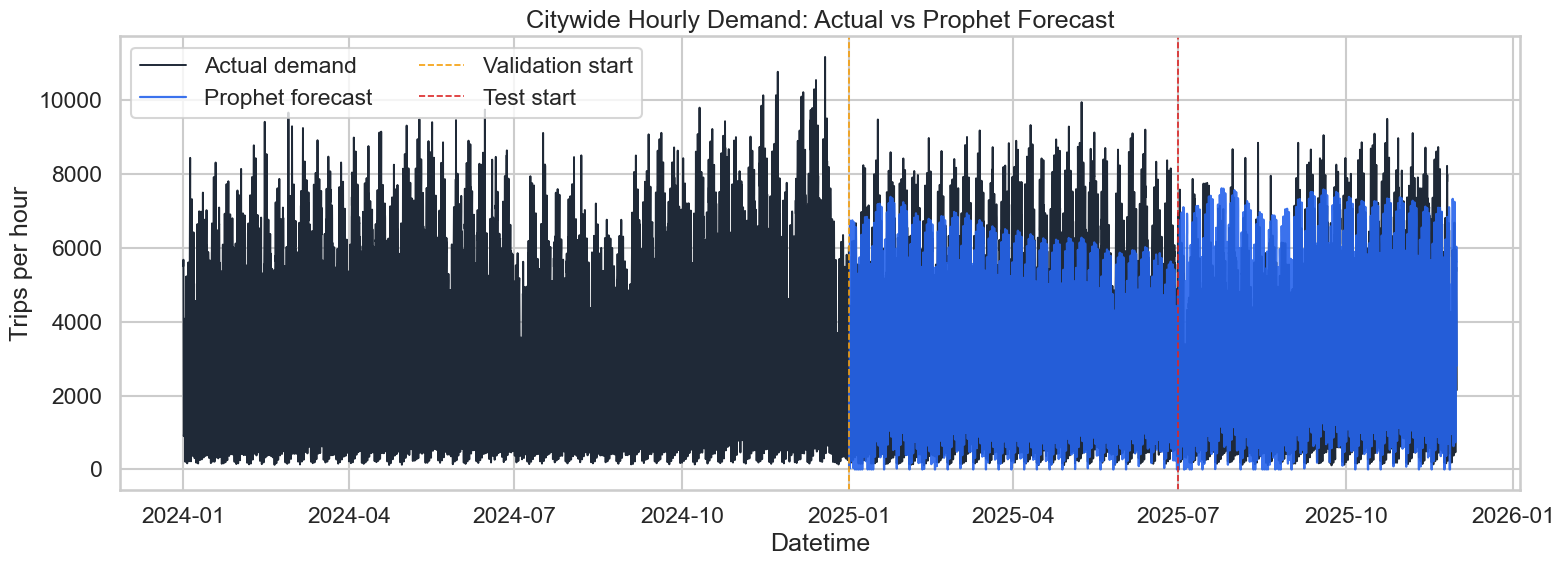

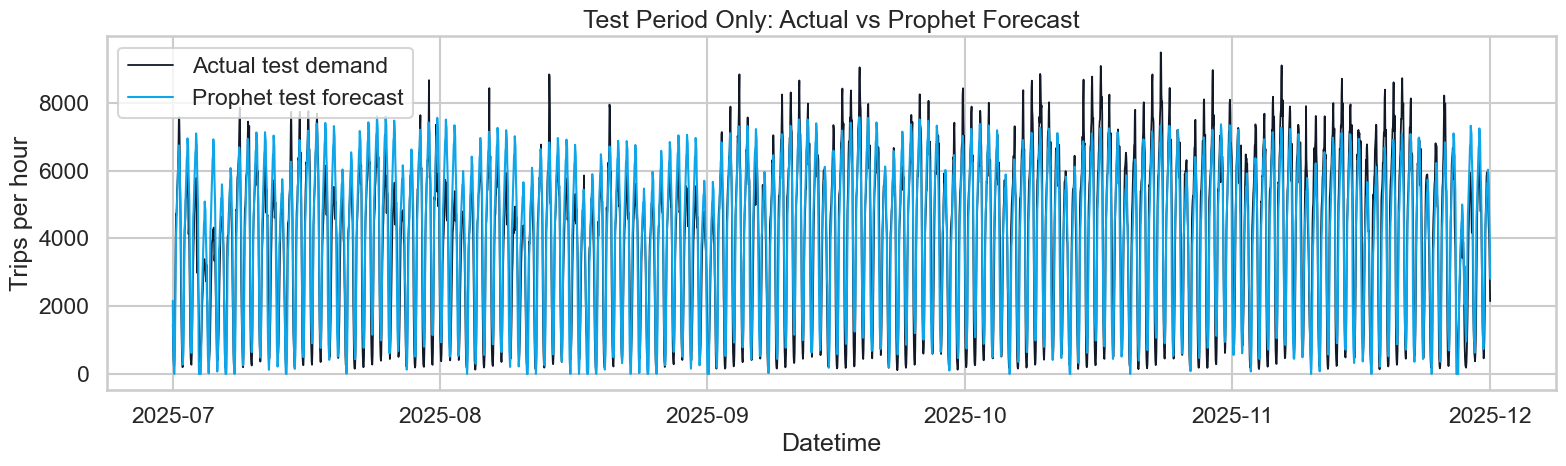

,ds,y,yhat
16793,2025-11-30 19:00:00,4365,5585.280088
16794,2025-11-30 20:00:00,4131,4791.167474
16795,2025-11-30 21:00:00,3675,4397.464819
16796,2025-11-30 22:00:00,2860,3906.657283
16797,2025-11-30 23:00:00,2150,2808.506509


In [55]:
# Step 5F: Historical actual vs forecast overlay
city_actual = city_hourly[['ds', 'y']].copy().sort_values('ds')

val_fc = pd.read_parquet(output_dir / 'prophet_city_val_predictions.parquet')[['ds', 'yhat']].copy()
test_fc = pd.read_parquet(output_dir / 'prophet_city_test_predictions.parquet')[['ds', 'yhat']].copy()
city_fc = pd.concat([val_fc, test_fc], ignore_index=True).drop_duplicates('ds').sort_values('ds')
plot_df = city_actual.merge(city_fc, on='ds', how='left')

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(plot_df['ds'], plot_df['y'], label='Actual demand', color=BRAND['light'], linewidth=1.4)
ax.plot(plot_df['ds'], plot_df['yhat'], label='Prophet forecast', color=BRAND['yellow'], linewidth=1.8)
ombre_fill(ax, plot_df['ds'], plot_df['yhat'].fillna(0), BRAND['yellow'])
ax.axvline(pd.Timestamp('2025-01-01'), color=BRAND['blue'], linestyle='--', linewidth=1.2, label='Validation start')
ax.axvline(pd.Timestamp('2025-07-01'), color=BRAND['orange'], linestyle='--', linewidth=1.2, label='Test start')
stylize_ax(ax, 'Citywide Hourly Demand: Actual vs Prophet Forecast')
ax.set_xlabel('Datetime')
ax.set_ylabel('Trips per hour')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig(plot_dir / 'city_actual_vs_forecast_overlay.png', dpi=170, bbox_inches='tight')
plt.show()

# Zoomed test-period comparison
test_zoom = plot_df[plot_df['ds'] >= pd.Timestamp('2025-07-01')].copy()
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_zoom['ds'], test_zoom['y'], label='Actual test demand', color=BRAND['light'], linewidth=1.3)
ax.plot(test_zoom['ds'], test_zoom['yhat'], label='Prophet test forecast', color=BRAND['gold'], linewidth=1.8)
ombre_fill(ax, test_zoom['ds'], test_zoom['yhat'].fillna(0), BRAND['gold'])
stylize_ax(ax, 'Test Period: Actual vs Prophet Forecast')
ax.set_xlabel('Datetime')
ax.set_ylabel('Trips per hour')
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / 'city_test_actual_vs_forecast_overlay.png', dpi=170, bbox_inches='tight')
plt.show()

plot_df.tail()


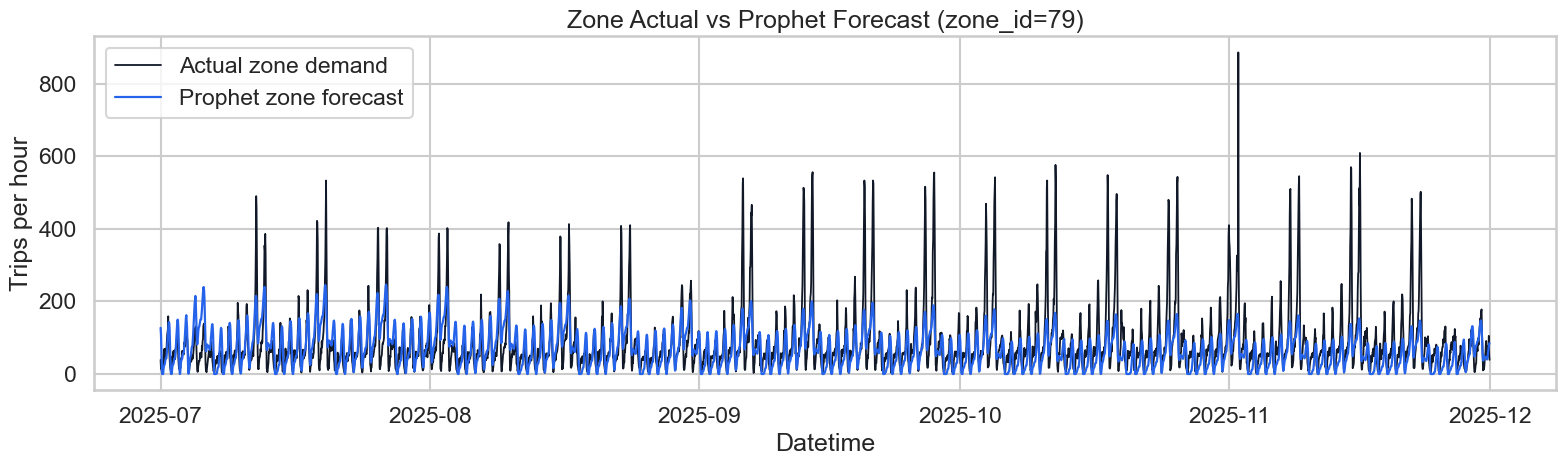

,ds,y,yhat,zone_id
69294,2025-11-30 19:00:00,71,60.337711,79
69295,2025-11-30 20:00:00,61,67.250758,79
69296,2025-11-30 21:00:00,105,75.769493,79
69297,2025-11-30 22:00:00,51,83.481309,79
69298,2025-11-30 23:00:00,39,84.604609,79


In [58]:
# Step 5G: Zone actual vs Prophet forecast overlay
zone_pred_path = output_dir / 'prophet_top_zone_test_predictions.parquet'
if not zone_pred_path.exists():
    raise FileNotFoundError(f'Missing {zone_pred_path}. Run Step 4B first.')

zone_pred = pd.read_parquet(zone_pred_path)
if zone_pred.empty:
    raise ValueError('Top-zone prediction file is empty.')

zone_counts = zone_pred.groupby('zone_id').size().sort_values(ascending=False)
plot_zone_id = int(zone_counts.index[0])
zone_plot = zone_pred[zone_pred['zone_id'] == plot_zone_id].sort_values('ds').copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(zone_plot['ds'], zone_plot['y'], label='Actual zone demand', color=BRAND['light'], linewidth=1.3)
ax.plot(zone_plot['ds'], zone_plot['yhat'], label='Prophet zone forecast', color=BRAND['yellow'], linewidth=1.8)
ombre_fill(ax, zone_plot['ds'], zone_plot['yhat'].fillna(0), BRAND['yellow'])
stylize_ax(ax, f'Zone Actual vs Prophet Forecast (zone_id={plot_zone_id})')
ax.set_xlabel('Datetime')
ax.set_ylabel('Trips per hour')
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / f'zone_actual_vs_prophet_zone_{plot_zone_id}.png', dpi=170, bbox_inches='tight')
plt.show()

zone_plot.tail()


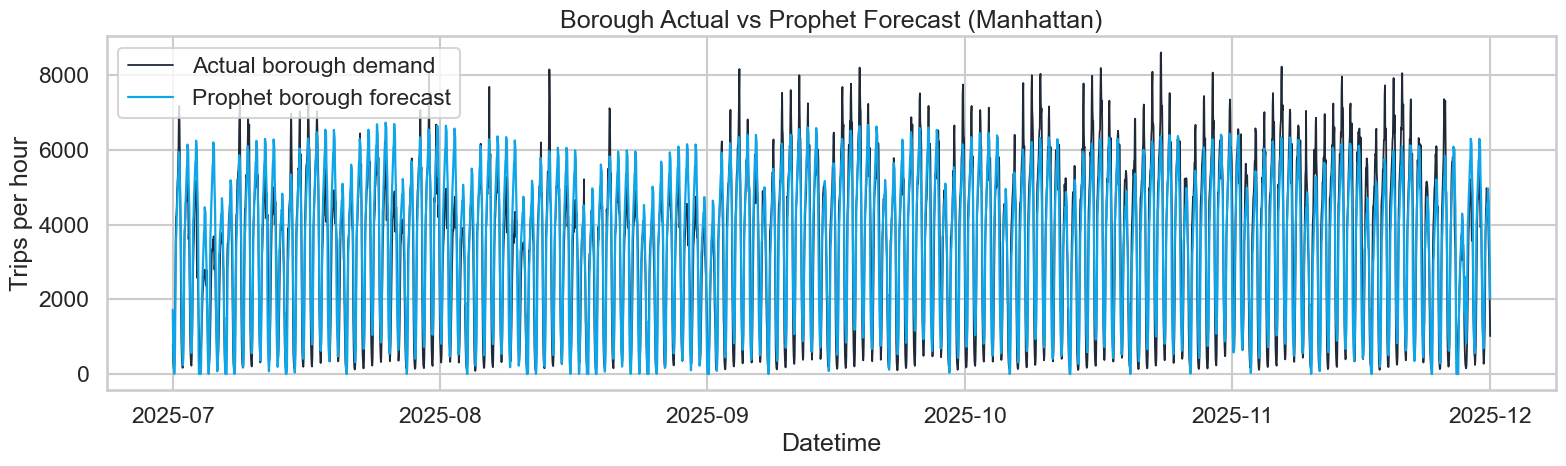

,ds,y,yhat,Borough
12388,2025-11-30 19:00:00,3438,4606.288028,Manhattan
12389,2025-11-30 20:00:00,3128,3831.936905,Manhattan
12390,2025-11-30 21:00:00,2636,3435.171491,Manhattan
12391,2025-11-30 22:00:00,1695,2964.820648,Manhattan
12392,2025-11-30 23:00:00,1014,2011.261354,Manhattan


In [59]:
# Step 5H: Borough actual vs Prophet forecast overlay
borough_pred_path = output_dir / 'prophet_borough_test_predictions.parquet'
if not borough_pred_path.exists():
    raise FileNotFoundError(f'Missing {borough_pred_path}. Run Step 4A first.')

borough_pred = pd.read_parquet(borough_pred_path)
if borough_pred.empty:
    raise ValueError('Borough prediction file is empty.')

borough_counts = borough_pred.groupby('Borough').size().sort_values(ascending=False)
plot_borough = borough_counts.index[0]
borough_plot = borough_pred[borough_pred['Borough'] == plot_borough].sort_values('ds').copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(borough_plot['ds'], borough_plot['y'], label='Actual borough demand', color=BRAND['light'], linewidth=1.3)
ax.plot(borough_plot['ds'], borough_plot['yhat'], label='Prophet borough forecast', color=BRAND['amber'], linewidth=1.8)
ombre_fill(ax, borough_plot['ds'], borough_plot['yhat'].fillna(0), BRAND['amber'])
stylize_ax(ax, f'Borough Actual vs Prophet Forecast ({plot_borough})')
ax.set_xlabel('Datetime')
ax.set_ylabel('Trips per hour')
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / f'borough_actual_vs_prophet_{plot_borough}.png', dpi=170, bbox_inches='tight')
plt.show()

borough_plot.tail()


In [56]:
# Step 6: Unified model leaderboard (city, borough, zone, hierarchical)
from sklearn.metrics import mean_absolute_error, mean_squared_error

city_cmp = pd.read_csv(output_dir / 'city_val_model_comparison.csv')
city_test_cmp = pd.read_csv(output_dir / 'city_test_model_comparison.csv')
city_all = pd.concat([city_cmp, city_test_cmp], ignore_index=True)
city_all['scope'] = 'city'
city_all['coverage_pct'] = 100.0

borough_metrics = pd.read_csv(output_dir / 'prophet_borough_metrics.csv')
borough_leader = borough_metrics.groupby(['split'], as_index=False)[['mae', 'rmse', 'mape_pct', 'n_rows']].mean()
borough_leader['model'] = 'prophet_borough_mean_over_segments'
borough_leader['scope'] = 'borough'
borough_leader['coverage_pct'] = 100.0

borough_baseline = pd.read_csv(output_dir / 'baseline_borough_metrics.csv')
borough_baseline['scope'] = 'borough'
borough_baseline['coverage_pct'] = 100.0

zone_top_baseline = pd.read_csv(output_dir / 'baseline_top_zone_metrics.csv')
zone_all_baseline = pd.read_csv(output_dir / 'baseline_all_zone_metrics.csv')

def agg_metrics_from_pred(path, split_name, model_name):
    df = pd.read_parquet(path)
    return pd.DataFrame([{
        'model': model_name,
        'split': split_name,
        'mae': float(mean_absolute_error(df['y'], df['yhat'])),
        'rmse': float(mean_squared_error(df['y'], df['yhat']) ** 0.5),
        'mape_pct': float((np.abs((df['y'] - df['yhat']) / df['y']).replace([np.inf, -np.inf], np.nan).dropna()).mean() * 100),
        'n_rows': int(len(df)),
    }])

top_zone_val = agg_metrics_from_pred(output_dir / 'prophet_top_zone_val_predictions.parquet', 'validation', 'prophet_top_zone')
top_zone_test = agg_metrics_from_pred(output_dir / 'prophet_top_zone_test_predictions.parquet', 'test', 'prophet_top_zone')
top_zone_leader = pd.concat([top_zone_val, top_zone_test], ignore_index=True)
top_zone_leader['scope'] = 'top_zones_only'

zone_val_rows = len(zone_val)
zone_test_rows = len(zone_test)
top_zone_leader['coverage_pct'] = top_zone_leader.apply(lambda r: 100.0 * r['n_rows'] / (zone_val_rows if r['split'] == 'validation' else zone_test_rows), axis=1)
zone_top_baseline['scope'] = 'top_zones_only'
zone_top_baseline['coverage_pct'] = zone_top_baseline.apply(lambda r: 100.0 * r['n_rows'] / (zone_val_rows if r['split'] == 'validation' else zone_test_rows), axis=1)
zone_all_baseline['scope'] = 'all_zones'
zone_all_baseline['coverage_pct'] = zone_all_baseline.apply(lambda r: 100.0 * r['n_rows'] / (zone_val_rows if r['split'] == 'validation' else zone_test_rows), axis=1)

hier = pd.read_csv(output_dir / 'hierarchical_prophet_metrics.csv')
hier_overall = hier[hier['zone_type'].isna()][['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows']].copy()
hier_overall['scope'] = 'all_zones_with_fallback'
hier_overall['coverage_pct'] = 100.0

leaderboard = pd.concat([
    city_all[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    borough_baseline[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    borough_leader[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    zone_top_baseline[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    top_zone_leader[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    zone_all_baseline[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
    hier_overall[['model', 'split', 'mae', 'rmse', 'mape_pct', 'n_rows', 'scope', 'coverage_pct']],
], ignore_index=True)

leaderboard = leaderboard.sort_values(['split', 'scope', 'rmse']).reset_index(drop=True)
leaderboard.to_csv(output_dir / 'unified_model_leaderboard.csv', index=False)
display(leaderboard)

for sp in ['validation', 'test']:
    print('')
    print('Split:', sp)
    display(leaderboard[leaderboard['split'] == sp][['model', 'scope', 'rmse', 'mae', 'mape_pct', 'coverage_pct', 'n_rows']])


,model,split,mae,rmse,mape_pct,n_rows,scope,coverage_pct
0,seasonal_naive_all_zone_lag24,test,10.069253,26.046791,82.809155,451360.0,all_zones,99.990474
1,hierarchical_prophet,test,1038.658915,2073.392117,25832.300329,451403.0,all_zones_with_fallback,100.000000
2,prophet_borough_mean_over_segments,test,151.968310,380.556334,52.072079,19866.0,borough,100.000000
3,seasonal_naive_borough_lag24,test,140.006645,408.824450,58.413773,19866.0,borough,100.000000
4,prophet_city_h1h2_time_regressors,test,725.836440,905.256221,41.345110,3672.0,city,100.000000
5,seasonal_naive_lag24,test,631.844499,928.112877,32.608555,3672.0,city,100.000000
6,prophet_top_zone,test,29.750098,44.439954,77.535362,109190.0,top_zones_only,24.189028
7,seasonal_naive_top_zone_lag24,test,29.505788,49.844164,76.798127,109190.0,top_zones_only,24.189028
8,seasonal_naive_all_zone_lag24,validation,12.057049,29.717916,81.620809,467844.0,all_zones,99.989100
9,hierarchical_prophet,validation,1060.928668,2146.858538,22589.637169,467895.0,all_zones_with_fallback,100.000000



Split: validation


,model,scope,rmse,mae,mape_pct,coverage_pct,n_rows
8,seasonal_naive_all_zone_lag24,all_zones,29.717916,12.057049,81.620809,99.989100,467844.0
9,hierarchical_prophet,all_zones_with_fallback,2146.858538,1060.928668,22589.637169,100.000000,467895.0
10,prophet_borough_mean_over_segments,borough,433.850270,192.190076,64.125580,100.000000,22976.0
11,seasonal_naive_borough_lag24,borough,472.255400,158.716617,63.040295,100.000000,22976.0
12,seasonal_naive_lag24,city,1052.917679,718.929312,NaN,100.000000,4343.0
13,prophet_city_h1h2_time_regressors,city,1132.332995,903.091376,NaN,100.000000,4343.0
14,seasonal_naive_top_zone_lag24,top_zones_only,53.433184,32.236686,79.663309,27.586959,129078.0
15,prophet_top_zone,top_zones_only,81.479006,47.874284,72.480540,27.586959,129078.0



Split: test


,model,scope,rmse,mae,mape_pct,coverage_pct,n_rows
0,seasonal_naive_all_zone_lag24,all_zones,26.046791,10.069253,82.809155,99.990474,451360.0
1,hierarchical_prophet,all_zones_with_fallback,2073.392117,1038.658915,25832.300329,100.000000,451403.0
2,prophet_borough_mean_over_segments,borough,380.556334,151.968310,52.072079,100.000000,19866.0
3,seasonal_naive_borough_lag24,borough,408.824450,140.006645,58.413773,100.000000,19866.0
4,prophet_city_h1h2_time_regressors,city,905.256221,725.836440,41.345110,100.000000,3672.0
5,seasonal_naive_lag24,city,928.112877,631.844499,32.608555,100.000000,3672.0
6,prophet_top_zone,top_zones_only,44.439954,29.750098,77.535362,24.189028,109190.0
7,seasonal_naive_top_zone_lag24,top_zones_only,49.844164,29.505788,76.798127,24.189028,109190.0


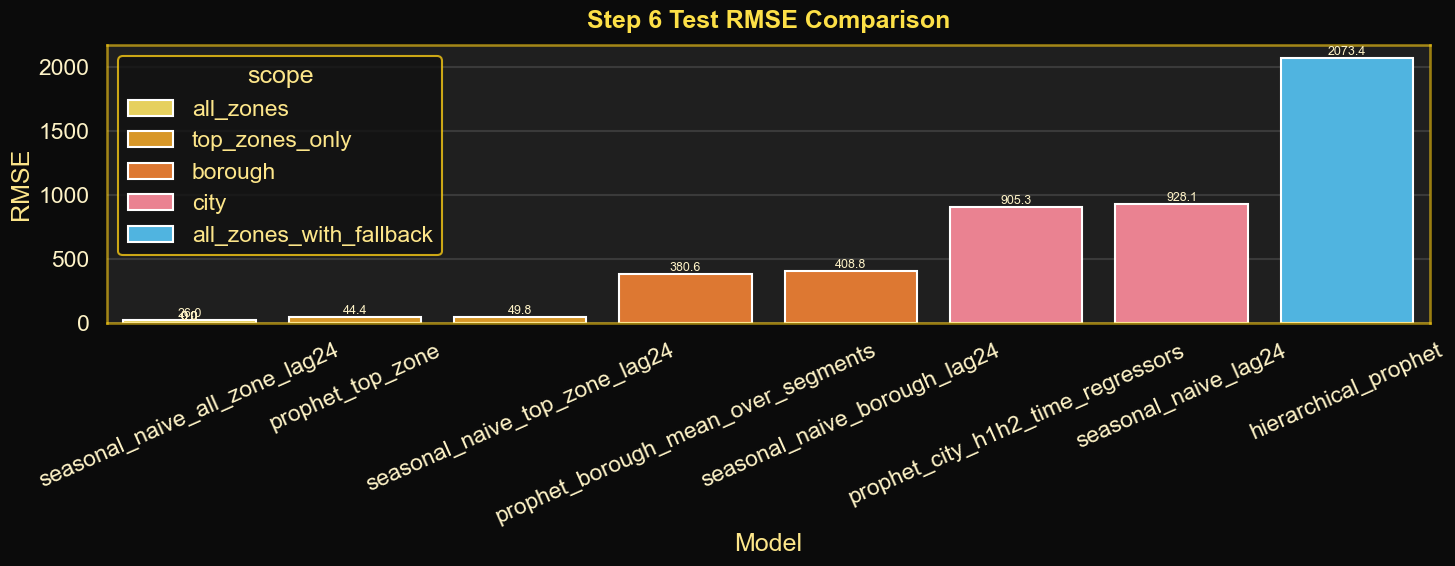

,model,scope,rmse,mae,mape_pct,coverage_pct,n_rows
0,seasonal_naive_all_zone_lag24,all_zones,26.046791,10.069253,82.809155,99.990474,451360.0
6,prophet_top_zone,top_zones_only,44.439954,29.750098,77.535362,24.189028,109190.0
7,seasonal_naive_top_zone_lag24,top_zones_only,49.844164,29.505788,76.798127,24.189028,109190.0
2,prophet_borough_mean_over_segments,borough,380.556334,151.968310,52.072079,100.000000,19866.0
3,seasonal_naive_borough_lag24,borough,408.824450,140.006645,58.413773,100.000000,19866.0
4,prophet_city_h1h2_time_regressors,city,905.256221,725.836440,41.345110,100.000000,3672.0
5,seasonal_naive_lag24,city,928.112877,631.844499,32.608555,100.000000,3672.0
1,hierarchical_prophet,all_zones_with_fallback,2073.392117,1038.658915,25832.300329,100.000000,451403.0


In [69]:
# Step 6A: Leaderboard comparison chart
from pathlib import Path

# Self-contained path and style fallbacks
if 'repo_root' not in globals():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents, Path.home() / 'Documents/GitHub/nyc-mobility-analysis', Path.home() / 'Downloads/GitHub/nyc-mobility-analysis']
    repo_root = next((p for p in candidates if (p / 'data' / 'processed').exists()), None)
    if repo_root is None:
        raise FileNotFoundError('Could not resolve repo_root')

if 'output_dir' not in globals():
    output_dir = repo_root / 'data' / 'interim' / 'prophet'
if 'plot_dir' not in globals():
    plot_dir = output_dir / 'plots'
    plot_dir.mkdir(parents=True, exist_ok=True)

if 'BRAND' not in globals():
    BRAND = {
        'yellow': '#facc15',
        'gold': '#fde047',
        'amber': '#f59e0b',
        'ink': '#0b0b0b',
        'slate': '#1f1f1f',
        'light': '#fef3c7',
    }

if 'OMBR_MIX' not in globals():
    OMBR_MIX = ['#fde047', '#f59e0b', '#f97316', '#fb7185', '#38bdf8']

if 'stylize_ax' not in globals():
    def stylize_ax(ax, title):
        ax.set_title(title, pad=12, fontweight='bold', color=BRAND['gold'])
        ax.set_facecolor(BRAND['slate'])
        for spine in ax.spines.values():
            spine.set_color(BRAND['yellow'])
            spine.set_alpha(0.6)

leaderboard_path = output_dir / 'unified_model_leaderboard.csv'
if not leaderboard_path.exists():
    raise FileNotFoundError(f'Missing {leaderboard_path}. Run Step 6 first.')

lb = pd.read_csv(leaderboard_path)
required_cols = {'model','scope','split','rmse','mae','mape_pct','coverage_pct','n_rows'}
missing = required_cols - set(lb.columns)
if missing:
    raise ValueError(f'Leaderboard missing columns: {missing}')

lb_test = lb[lb['split'] == 'test'].copy().sort_values('rmse')
if lb_test.empty:
    raise ValueError('No test rows in unified_model_leaderboard.csv')

fig, ax = plt.subplots(figsize=(15, 6), facecolor=BRAND['ink'])
sns.barplot(data=lb_test, x='model', y='rmse', hue='scope', palette=OMBR_MIX, ax=ax)
stylize_ax(ax, 'Step 6 Test RMSE Comparison')
ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=24)
for patch in ax.patches:
    h = patch.get_height()
    if h == h:
        ax.annotate(f'{h:.1f}', (patch.get_x() + patch.get_width()/2., h), ha='center', va='bottom', fontsize=9, color=BRAND['light'])

plt.tight_layout()
plt.savefig(plot_dir / 'step6_test_rmse_comparison.png', dpi=170, bbox_inches='tight')
plt.show()

lb_test[['model','scope','rmse','mae','mape_pct','coverage_pct','n_rows']]


/var/folders/rl/2kbvhn0n0mqct77jtc2_t8740000gn/T/ipykernel_96253/3887483803.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: float(mean_squared_error(d['y'], d['yhat']) ** 0.5))


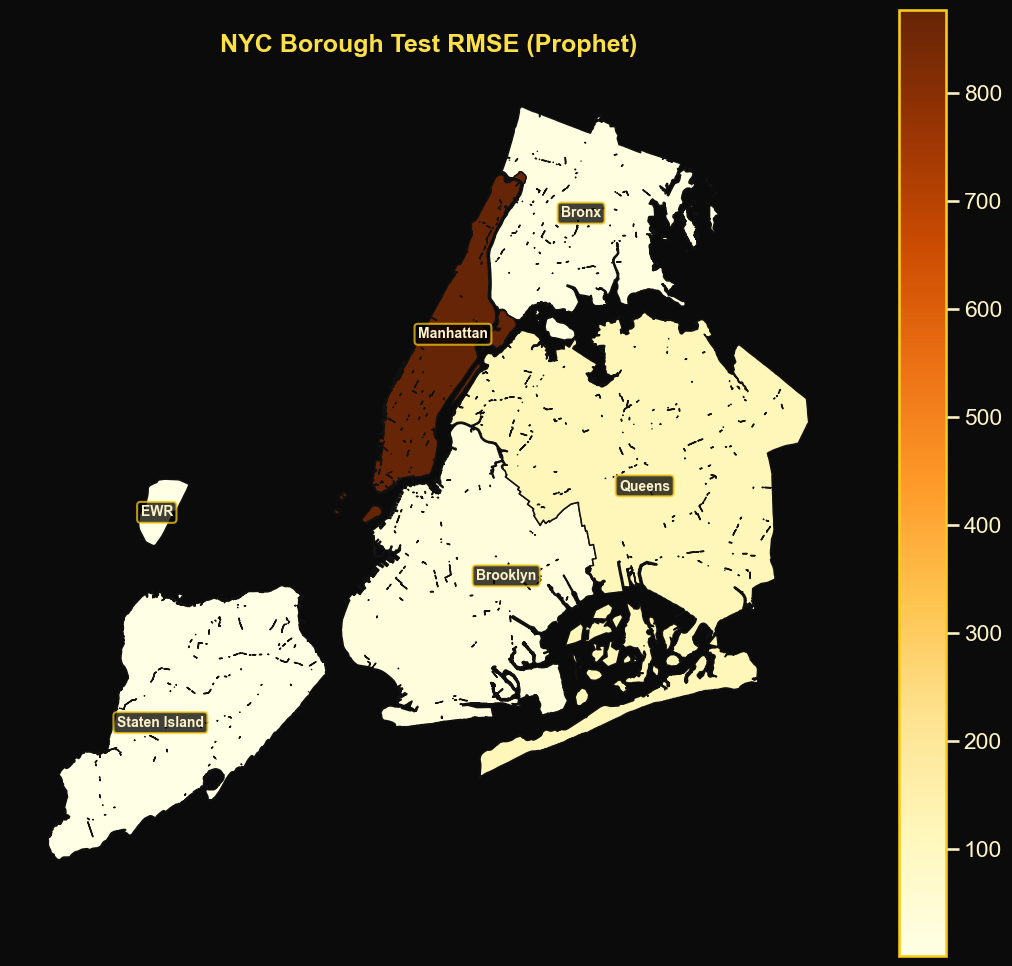

,Borough,rmse
5,Staten Island,0.497833
2,EWR,1.106901
6,Unknown,4.182470
0,Bronx,14.254992
1,Brooklyn,27.977637
4,Queens,116.588794
3,Manhattan,876.883727


In [68]:
# Step 6B: NYC borough map color-coded by RMSE (with labels)
import geopandas as gpd
from sklearn.metrics import mean_squared_error
from pathlib import Path

# Self-contained paths and style fallback
if 'repo_root' not in globals():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents, Path.home() / 'Documents/GitHub/nyc-mobility-analysis', Path.home() / 'Downloads/GitHub/nyc-mobility-analysis']
    repo_root = next((p for p in candidates if (p / 'data' / 'processed').exists()), None)
    if repo_root is None:
        raise FileNotFoundError('Could not resolve repo_root')

if 'output_dir' not in globals():
    output_dir = repo_root / 'data' / 'interim' / 'prophet'
if 'plot_dir' not in globals():
    plot_dir = output_dir / 'plots'
    plot_dir.mkdir(parents=True, exist_ok=True)

if 'BRAND' not in globals():
    BRAND = {
        'yellow': '#facc15',
        'gold': '#fde047',
        'amber': '#f59e0b',
        'ink': '#0b0b0b',
        'slate': '#1f1f1f',
        'light': '#fef3c7',
    }

if 'stylize_ax' not in globals():
    def stylize_ax(ax, title):
        ax.set_title(title, pad=12, fontweight='bold', color=BRAND['gold'])
        ax.set_facecolor(BRAND['slate'])
        for spine in ax.spines.values():
            spine.set_color(BRAND['yellow'])
            spine.set_alpha(0.6)

shape_path = repo_root / 'data' / 'external' / 'taxi_zones' / 'taxi_zones' / 'taxi_zones.shp'
if not shape_path.exists():
    raise FileNotFoundError(f'Missing shapefile: {shape_path}')

gdf = gpd.read_file(shape_path)

# Normalize columns from shapefile
rename_map = {}
if 'LocationID' in gdf.columns:
    rename_map['LocationID'] = 'zone_id'
if 'borough' in gdf.columns:
    rename_map['borough'] = 'Borough'
if 'zone' in gdf.columns:
    rename_map['zone'] = 'Zone'
gdf = gdf.rename(columns=rename_map)

required = {'zone_id', 'Borough', 'geometry'}
missing = required - set(gdf.columns)
if missing:
    raise ValueError(f'Shapefile missing required columns: {missing}')

borough_pred_path = output_dir / 'prophet_borough_test_predictions.parquet'
if not borough_pred_path.exists():
    raise FileNotFoundError(f'Missing {borough_pred_path}. Run Step 4A first.')
borough_pred = pd.read_parquet(borough_pred_path)
if borough_pred.empty:
    raise ValueError('Borough prediction file is empty.')

borough_rmse = (
    borough_pred.groupby('Borough')
    .apply(lambda d: float(mean_squared_error(d['y'], d['yhat']) ** 0.5))
    .rename('rmse')
    .reset_index()
)

# Dissolve taxi zones into borough polygons for clean labels
borough_map = (
    gdf.merge(borough_rmse, on='Borough', how='left')
    .dissolve(by='Borough', aggfunc={'rmse': 'mean'})
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(11, 10), facecolor=BRAND['ink'])
ax.set_facecolor(BRAND['slate'])
borough_map.plot(
    column='rmse',
    cmap='YlOrBr',
    linewidth=1.1,
    edgecolor='#111111',
    legend=True,
    ax=ax,
    missing_kwds={'color': '#2a2a2a', 'label': 'No RMSE'}
)
stylize_ax(ax, 'NYC Borough Test RMSE (Prophet)')
ax.axis('off')

# Add borough labels at polygon centroids
for _, row in borough_map.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    pt = row.geometry.representative_point()
    ax.text(
        pt.x,
        pt.y,
        row['Borough'],
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=BRAND['light'],
        bbox=dict(boxstyle='round,pad=0.25', facecolor='#000000', edgecolor=BRAND['yellow'], alpha=0.75),
    )

plt.tight_layout()
plt.savefig(plot_dir / 'nyc_borough_rmse_map.png', dpi=180, bbox_inches='tight')
plt.show()

display(borough_rmse.sort_values('rmse'))
